# Google Trends Analysis — Disease Surveillance Keywords

Reads the raw data produced by `trends_extract.py` and produces:
- `trends_subtype_means.csv` — monthly z-score mean per sub-type per country
- `trends_timeseries.png` — 6-panel faceted time-series chart

**Prerequisites:** run `trends_extract.py` first to generate `trends_raw_data.csv`.

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import numpy as np
import calendar
from pygam import LinearGAM, s

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Update these if your files are in a different location.

RAW_DATA_CSV  = Path("trends_normalised_data.csv")    # produced by trends_extract.py
ANCHORS_CSV   = Path("trends_anchors.csv")      # produced by trends_extract.py
KEYWORDS_CSV  = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance"
                     r"\One_Health_Proposal_Eugenia\Datasets\Google_dataset.csv")
CSV_PATH  = r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Datasets"
KEYWORDS_ENCODING = "cp1252"
OUTPUT_PATH    = Path(".")

# ── Visual design ─────────────────────────────────────────────────────────────
SUBTYPE_COLOURS: dict[str, str] = {
    "Aedes":       "#E69F00",
    "Chikungunya": "#56B4E9",
    "Dengue":      "#009E73",
    "Zika":        "#F0E442",
    "Culex":       "#0072B2",
    "Usutu":       "#D55E00",
    "West Nile":   "#CC79A7",
}

COUNTRY_COLOURS: dict[str, str] = {
    "DE":       "#E69F00",
    "AT":       "#56B4E9",
    "CH":       "#009E73",
    "FR":       "#0072B2",
    "ES":       "#F0E442",
    "IT":       "#CC79A7",
}

SYSTEM_COLOURS: dict[str, str] = {
    "Aedes-borne disease system": "#0072B2",
    "Culex-borne disease system": "#D55E00",
}

SYSTEM_STYLES: dict[str, str] = {
    "Aedes-borne disease system": "dashed",
    "Culex-borne disease system": "solid",
}

COUNTRY_LABELS: dict[str, str] = {
    "DE": "Germany",
    "AT": "Austria",
    "CH": "Switzerland",
    "IT": "Italy",
    "ES": "Spain",
    "FR": "France",
}

# Preferred country order in the figure
COUNTRY_ORDER = ["DE", "AT", "CH", "IT", "ES", "FR"]

# Must match what was used in trends_extract.py
ANCHOR_PER_COUNTRY: dict[str, str] = {
    "DE": "Mücke",
    "AT": "Mücke",
    "CH": "Mücke",
    "IT": "Zanzara",
    "ES": "Mosquito",
    "FR": "Moustique",
}

## 1. Load Raw Data

In [3]:
# ── Load the wide-format raw CSV produced by trends_extract.py ───────────────
# Columns are named "GEO::keyword", e.g. "DE::Dengue fieber"

raw_all = pd.read_csv(RAW_DATA_CSV, index_col=0, parse_dates=True)
anchors_raw = pd.read_csv(ANCHORS_CSV, index_col=0, parse_dates=True)
print(f"Loaded {raw_all.shape[1]} keyword-country columns × {len(raw_all)} time points")
raw_all.head()

Loaded 258 keyword-country columns × 192 time points


,DE::Aedes-Mücke,DE::Aedes Mücke,DE::Tigermücke,DE::Tiger Mücke,DE::Zika Virus,DE::Zikavirus,DE::Zika-Virus,DE::Zika-Fieber,DE::Zika Fieber,DE::Denguefieber,...,FR::Moustique Culex,FR::Virus Usutu,FR::Virus d’Usutu,FR::Aedes albopictus,FR::Zika,FR::Dengue,FR::Chikungunya,FR::Culex pipiens,FR::Culex torrentium,FR::Culex modestus
time [UTC],,,,,,,,,,,,,,,,,,,,,
2010-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,33.333333,0.0,0.0,0.0
2010-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,0.000000,0.0,0.0,0.0
2010-03-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,33.333333,0.000000,0.0,0.0,0.0
2010-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,25.000000,25.000000,0.0,0.0,0.0
2010-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.448276,...,0.0,0.0,0.0,0.0,0.0,16.666667,16.666667,0.0,0.0,0.0


In [4]:
# ── Split wide table back into per-country DataFrames ─────────────────────────
country_data: dict[str, pd.DataFrame] = {}

for geo in COUNTRY_ORDER:
    cols = [c for c in raw_all.columns if c.startswith(f"{geo}::")]
    if not cols:
        print(f"WARNING: no columns found for {geo} — was this country fetched?")
        continue
    sub = raw_all[cols].copy()
    sub.columns = [c.split("::", 1)[1] for c in cols]   # strip the "GEO::" prefix
    country_data[geo] = sub
    print(f"  {geo}: {len(cols)} keywords")

  DE: 36 keywords
  AT: 36 keywords
  CH: 90 keywords
  IT: 25 keywords
  ES: 25 keywords
  FR: 46 keywords


## 2. Load Keyword Metadata

In [5]:
kw_df = pd.read_csv(KEYWORDS_CSV, encoding=KEYWORDS_ENCODING)
kw_df.columns = kw_df.columns.str.strip()
for col in ["Keyword", "Language", "System", "Sub-type", "Type"]:
    kw_df[col] = kw_df[col].astype(str).str.strip()

# Build {keyword: {Sub-type, System, Type}} lookup (first occurrence wins for duplicates)
meta: dict[str, dict] = (
    kw_df.drop_duplicates(subset="Keyword")
         .set_index("Keyword")[["Sub-type", "System", "Type"]]
         .to_dict(orient="index")
)

print(f"Loaded metadata for {len(meta)} unique keywords")
print("Sub-types:", sorted({v['Sub-type'] for v in meta.values()}))
print("Systems  :", sorted({v['System']   for v in meta.values()}))

Loaded metadata for 122 unique keywords
Sub-types: ['Aedes', 'Chikungunya', 'Culex', 'Dengue', 'Usutu', 'West Nile', 'Zika']
Systems  : ['Aedes-borne disease system', 'Culex-borne disease system']


## 3. Calculate monthly mean per Sub-type per Country

Each keyword is averaged within a sub-type. Could change this to weighted mean for full (non-proposal) analysis.

In [17]:
def build_subtype_means(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
) -> dict[str, dict[str, pd.Series]]:
    """
    For each country × sub-type, calculate the mean of the
    anchor-normalised Google Trends values across all keywords
    in that sub-type.

    Returns
    -------
    {geo: {subtype: pd.Series(monthly mean interest)}}
    """
    all_subtypes = sorted({v["Sub-type"] for v in meta.values()})
    result: dict[str, dict[str, pd.Series]] = {}

    for geo, df in country_data.items():
        result[geo] = {}

        for subtype in all_subtypes:
            cols = [
                kw for kw in df.columns
                if kw in meta and meta[kw]["Sub-type"] == subtype
            ]

            if not cols:
                continue

            # Mean anchor-normalised interest across keywords
            result[geo][subtype] = df[cols].mean(axis=1)

    return result


subtype_means = build_subtype_means(country_data, meta)
print("Sub-type means computed for:", list(subtype_means.keys()))

Sub-type means computed for: ['DE', 'AT', 'CH', 'IT', 'ES', 'FR']


In [9]:
anchor_series: dict[str, pd.Series] = {}

for geo in COUNTRY_ORDER:
    anchor_word = ANCHOR_PER_COUNTRY.get(geo)
    col = f"{geo}::{anchor_word}"

    if col not in anchors_raw.columns:
        print(f"WARNING: anchor column '{col}' not found in {ANCHORS_CSV}")
        continue

    anchor_series[geo] = anchors_raw[col].dropna()

    print(
        f"  {geo}: anchor '{anchor_word}' loaded "
        f"({len(anchor_series[geo])} points)"
    )

anchor_series[geo].index = pd.to_datetime(anchor_series[geo].index)

  DE: anchor 'Mücke' loaded (192 points)
  AT: anchor 'Mücke' loaded (192 points)
  CH: anchor 'Mücke' loaded (189 points)
  IT: anchor 'Zanzara' loaded (192 points)
  ES: anchor 'Mosquito' loaded (192 points)
  FR: anchor 'Moustique' loaded (192 points)


## 4. Save Sub-type Means to CSV

In [ ]:
means_frames = []
for geo, subtypes in subtype_means.items():
    for subtype, series in subtypes.items():
        means_frames.append(series.rename(f"{geo}::{subtype}"))

means_df = pd.concat(means_frames, axis=1)
means_path = OUTPUT_PATH / "trends_subtype_means.csv"
means_df.to_csv(means_path)
print(f"Saved → {means_path}")
means_df.head()

Saved → trends_subtype_means.csv


,DE::Aedes,DE::Chikungunya,DE::Culex,DE::Dengue,DE::Usutu,DE::West Nile,DE::Zika,AT::Aedes,AT::Chikungunya,AT::Culex,...,ES::Usutu,ES::West Nile,ES::Zika,FR::Aedes,FR::Chikungunya,FR::Culex,FR::Dengue,FR::Usutu,FR::West Nile,FR::Zika
time [UTC],,,,,,,,,,,,,,,,,,,,,
2010-01-01,0.0,0.540541,0.0,10.325710,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,16.666667,0.0,2.083333,0.0,0.0,0.0
2010-02-01,0.0,0.714286,0.0,18.452381,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,2.083333,0.0,0.0,0.0
2010-03-01,0.0,0.689655,0.0,26.724138,0.0,0.0,1.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,2.083333,0.0,0.0,0.0
2010-04-01,0.0,0.000000,0.0,27.298851,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.250000,0.0,1.562500,0.0,0.0,0.0
2010-05-01,0.0,0.000000,0.0,25.632184,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.166667,0.0,1.041667,0.0,0.0,0.0


# Figures

In [6]:
subtype_means = pd.read_csv("trends_subtype_means.csv", index_col=0)
dengue = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Dengue.csv")
chik   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Chikungunya_virus_disease.csv")
wnv    = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_West_Nile_virus_infection.csv")
zika   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Zika_virus_infection.csv")

def prep_ecdc(df):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()

    # Convert Time (YYYY-MM) to datetime
    df["date"] = pd.to_datetime(df["time"], format="%Y-%m")

    # Clean numeric values
    df["numvalue"] = pd.to_numeric(df["numvalue"], errors="coerce").fillna(0)

    # Standardize names
    df = df.rename(columns={
        "regionname": "country",
        "numvalue": "cases"
    })

    return df[["country", "date", "cases"]]

dengue = prep_ecdc(dengue)
chik = prep_ecdc(chik)
wnv = prep_ecdc(wnv)
zika = prep_ecdc(zika)

In [7]:
def gam_smoother(
    x,
    y,
    x_grid=None,
    n_splines=12,
    ci_width=0.95,
    n_splines_trend=10
):
    """
    Generic GAM smoother with confidence intervals.

    Returns:
        x_grid, y_pred, lower, upper
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x_grid is None:
        x_grid = np.linspace(x.min(), x.max(), 200)

    gam = LinearGAM(s(0, n_splines=n_splines_trend)).fit(x, y)

    y_pred = gam.predict(x_grid)
    ci = gam.prediction_intervals(x_grid, width=ci_width)

    lower = ci[:, 0]
    upper = ci[:, 1]

    return x_grid, y_pred, lower, upper

def gam_smoother_seasonal(X, y, x_grid, ci_width=0.95):
    """
    GAM with 2D seasonal structure (sin/cos month encoding)
    """

    y = np.asarray(y)

    mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X = X[mask]
    y = y[mask]

    gam = LinearGAM(s(0) + s(1)).fit(X, y)

    y_pred = gam.predict(x_grid)
    ci = gam.prediction_intervals(x_grid, width=ci_width)

    return y_pred, ci[:, 0], ci[:, 1]

## Quickly investigate raw means

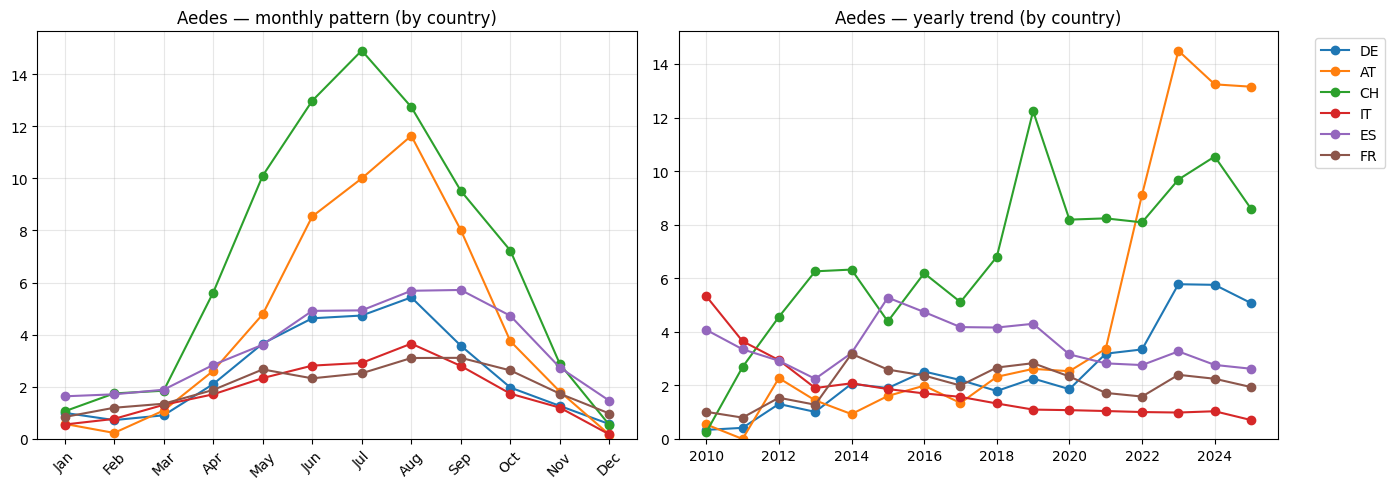

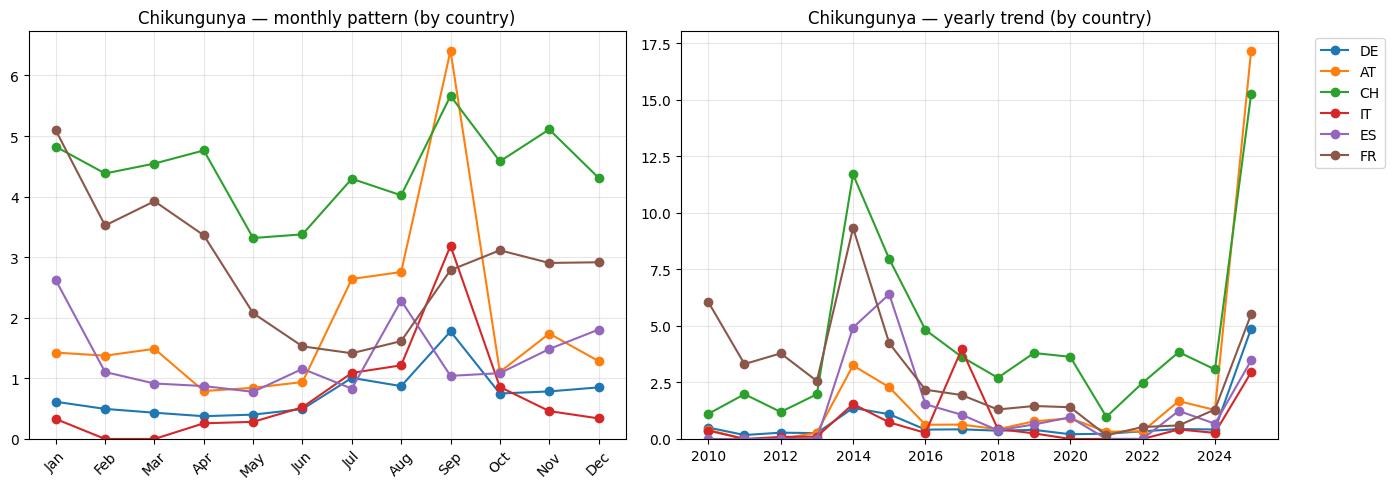

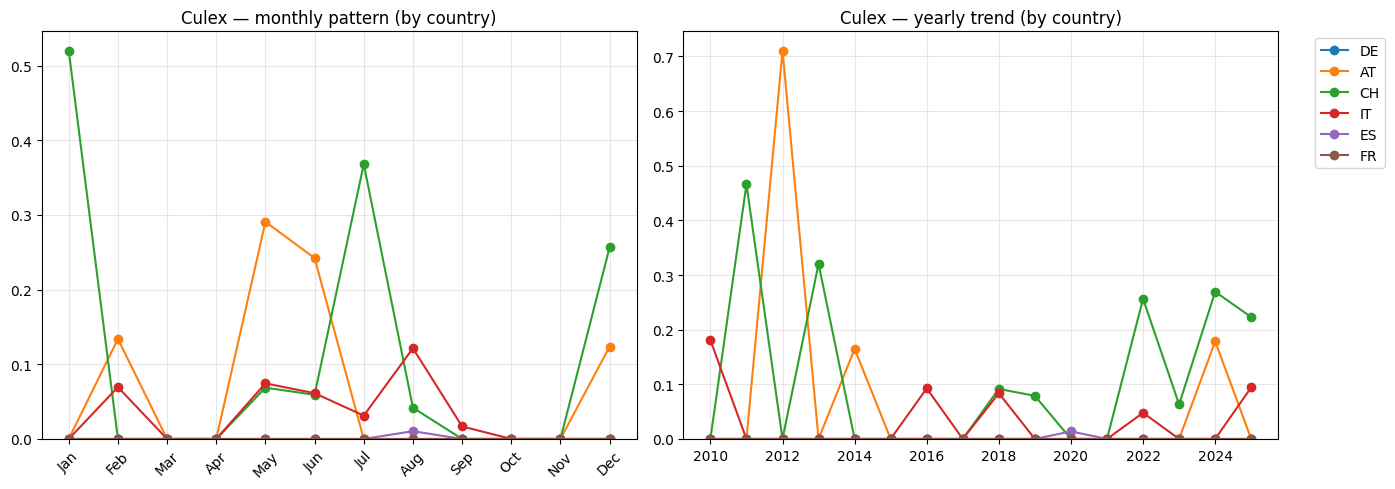

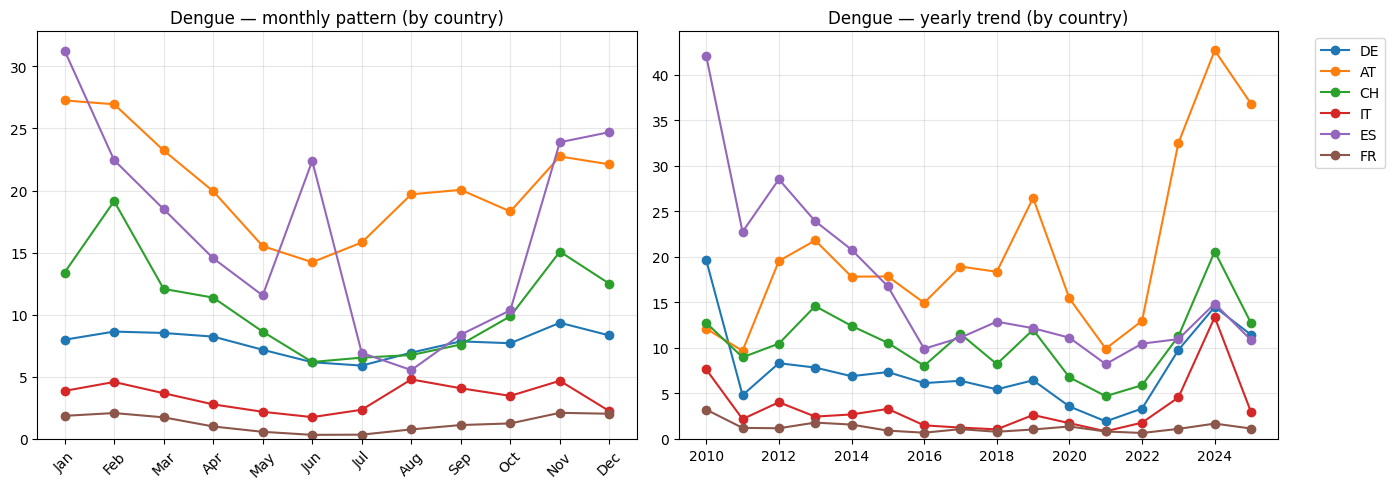

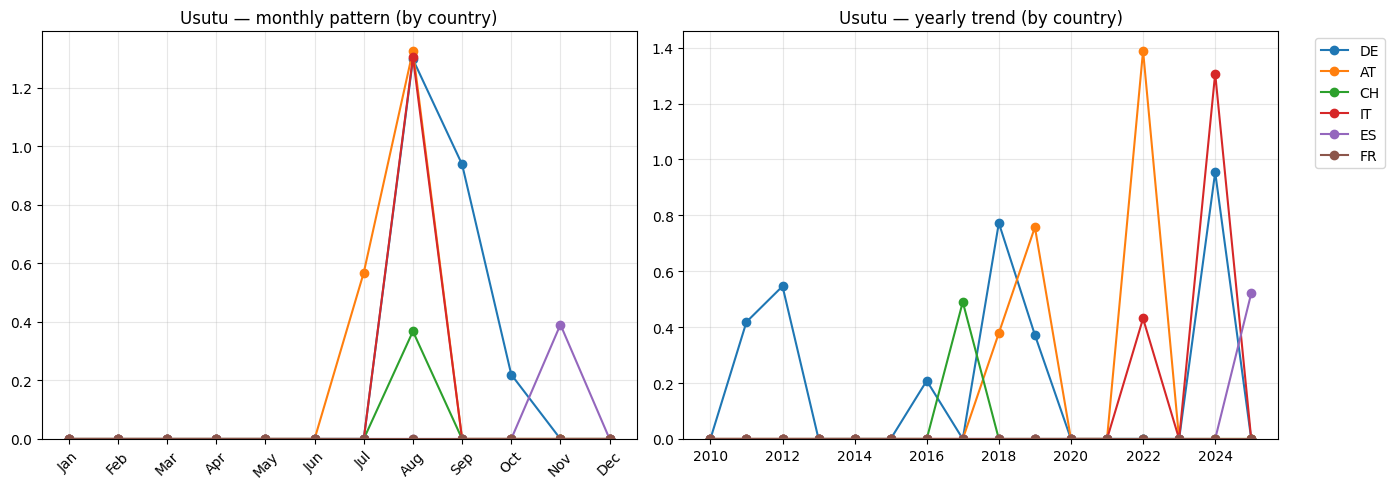

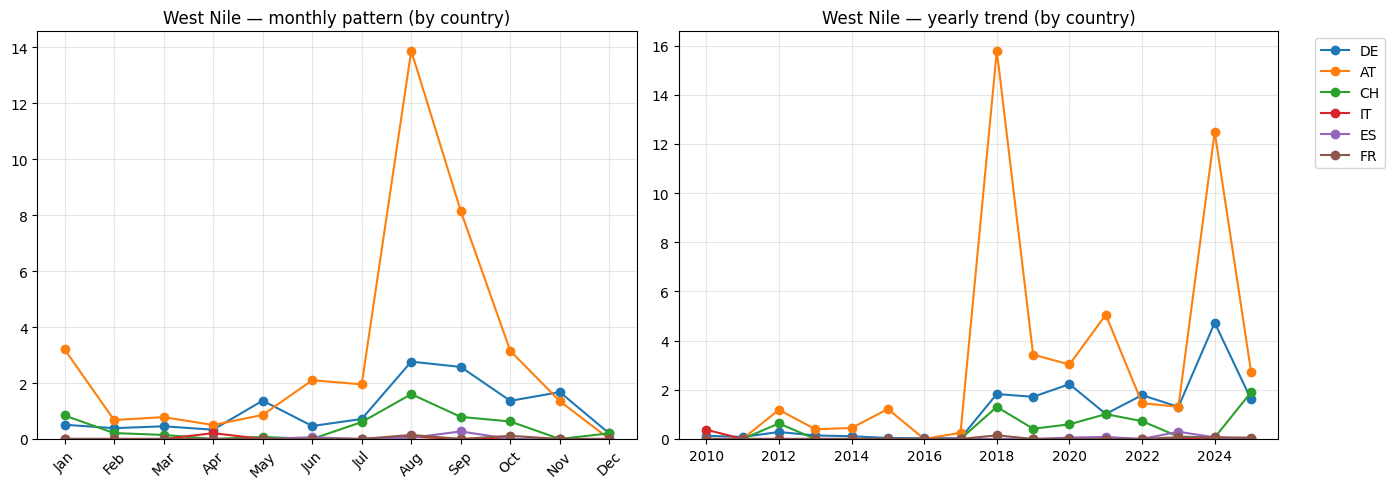

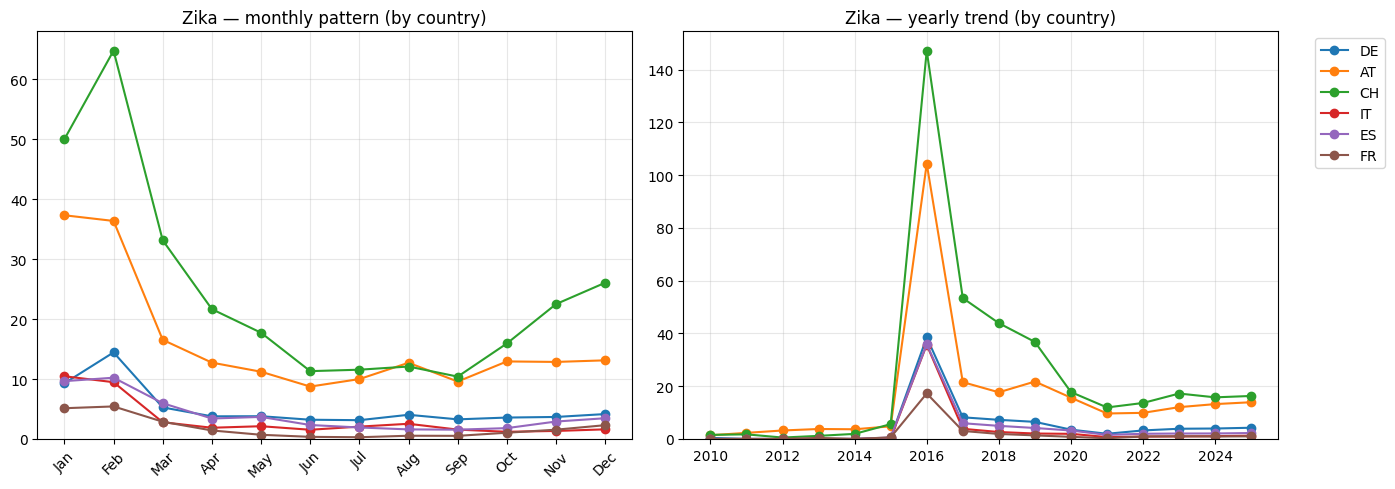

In [ ]:
def plot_subtype_country_diagnostics(subtype_means, country_order=None):
    """
    Diagnostic plots:
    - one figure per subtype
    - lines per country
    - monthly + yearly panels
    """

    df = subtype_means.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]
    subtypes = sorted({x[1] for x in col_tuples})
    countries = sorted({x[0] for x in col_tuples})

    if country_order is not None:
        countries = [c for c in country_order if c in countries]

    for subtype in subtypes:

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # =========================
        # MONTHLY PATTERN
        # =========================
        for country in countries:

            col = f"{country}::{subtype}"
            if col not in df.columns:
                continue

            s = df[col].dropna()
            if len(s) == 0:
                continue

            monthly = s.groupby(s.index.month).mean()

            ax[0].plot(
                monthly.index,
                monthly.values,
                marker="o",
                label=country
            )

        ax[0].set_title(f"{subtype} — monthly pattern (by country)")
        ax[0].set_xticks(range(1, 13))
        ax[0].set_xticklabels(
            ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"],
            rotation=45
        )
        ax[0].set_ylim(bottom=0)
        ax[0].grid(alpha=0.3)

        # =========================
        # YEARLY TREND
        # =========================
        for country in countries:

            col = f"{country}::{subtype}"
            if col not in df.columns:
                continue

            s = df[col].dropna()
            if len(s) == 0:
                continue

            yearly = s.groupby(s.index.year).mean()

            ax[1].plot(
                yearly.index,
                yearly.values,
                marker="o",
                label=country
            )

        ax[1].set_title(f"{subtype} — yearly trend (by country)")
        ax[1].set_ylim(bottom=0)
        ax[1].grid(alpha=0.3)

        # shared legend
        ax[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

plot_subtype_country_diagnostics(subtype_means, COUNTRY_ORDER)

## MAIN BODY - Monthly and yearly with barplot disease data

In [10]:
disease_lookup = {
    "Dengue": dengue,
    "Chikungunya": chik,
    "West Nile": wnv,
    "Zika": zika,
}

def plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    save_dir,
    freq="month",      # "month" or "year"
):
    """
    Creates one PDF per subtype (+ one Anchor figure).

    Lines:
        countries

    Disease subtypes:
        secondary axis with average ECDC case counts

    Anchor:
        no case bars
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df = subtype_means.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]

    countries = [
        c for c in COUNTRY_ORDER
        if c in {x[0] for x in col_tuples}
    ]

    subtypes = sorted({x[1] for x in col_tuples})

    plot_items = subtypes + ["__anchor__"]

    if freq == "month":
        xvals = range(1, 13)
        xticklabels = list(calendar.month_abbr)[1:]
        xlabel = "Month"
        width = 0.08
        offsets = np.linspace(-0.25, 0.25, len(countries))
    else:
        years = sorted(df.index.year.unique())
        xvals = years
        xticklabels = years
        xlabel = "Year"
        width = 0.10
        offsets = np.linspace(-0.30, 0.30, len(countries))

    for item in plot_items:
        # --- compute a threshold specific to this panel ---
        if item == "__anchor__":
            item_vals = np.concatenate([
                anchor_series[c].dropna().to_numpy()
                for c in countries if c in anchor_series
            ])
        else:
            cols = [f"{c}::{item}" for c in countries if f"{c}::{item}" in df.columns]
            item_vals = df[cols].to_numpy().ravel()

        threshold = np.nanpercentile(item_vals, 95)

        if item in disease_lookup:
            case_options = [False, True]   # save with and without cases
        else:
            case_options = [False]  

        if item in disease_lookup:
            case_options = [False, True]   # save with and without cases
        else:
            case_options = [False]         # only one plot (anchor)

        for show_cases in case_options:

            fig, ax = plt.subplots(figsize=(10,5))

            if item in disease_lookup and show_cases:
                ax2 = ax.twinx()
                ax.set_zorder(2)
                ax2.set_zorder(1)
                ax.patch.set_alpha(0)

            for offset, country in zip(offsets, countries):

                ####################################################
                # Google Trends
                ####################################################

                if item == "__anchor__":

                    if country not in anchor_series:
                        continue

                    series = anchor_series[country].copy()
                    series.index = pd.to_datetime(series.index)

                else:

                    col = f"{country}::{item}"

                    if col not in df.columns:
                        continue

                    series = df[col]

                if freq == "month":

                    series = series.dropna()

                    y_raw = series.values

                    month = series.index.month.values

                    X = np.column_stack([
                        np.sin(2 * np.pi * month / 12),
                        np.cos(2 * np.pi * month / 12)
                    ])

                    gam = LinearGAM(s(0) + s(1)).fit(X, y_raw)

                    month_grid = np.linspace(0, 11, 200)

                    X_grid = np.column_stack([
                        np.sin(2 * np.pi * month_grid / 12),
                        np.cos(2 * np.pi * month_grid / 12)
                    ])

                    y_pred = gam.predict(X_grid)
                    ci = gam.confidence_intervals(X_grid, width=0.95)

                    lower, upper = ci[:, 0], ci[:, 1]

                    color = COUNTRY_COLOURS.get(country)

                    ax.plot(
                        month_grid + 1,
                        y_pred,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                    ax.fill_between(
                        month_grid + 1,
                        lower,
                        upper,
                        color=color,
                        alpha=0.09,
                        zorder=2,
                    )

                else:

                    series = series.dropna()

                    x_raw = series.index.year.values
                    y_raw = series.values

                    # --- fit GAM (1D smooth trend over years) ---
                    gam = LinearGAM(s(0)).fit(x_raw, y_raw)

                    # --- prediction grid ---
                    x_grid = np.linspace(x_raw.min(), x_raw.max(), 200)

                    y_pred = gam.predict(x_grid)

                    ci = gam.confidence_intervals(x_grid, width=0.95)
                    lower, upper = ci[:, 0], ci[:, 1]

                    color = COUNTRY_COLOURS.get(country)

                    # --- trend line ---
                    ax.plot(
                        x_grid,
                        y_pred,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                    # --- confidence band ---
                    ax.fill_between(
                        x_grid,
                        lower,
                        upper,
                        color=color,
                        alpha=0.09,
                        zorder=2,
                    )

                ####################################################
                # Disease cases
                ####################################################

                if (item not in disease_lookup) or (not show_cases):
                    continue

                ddf = disease_lookup[item]

                country_name = COUNTRY_LABELS.get(country, country)

                dsub = (
                    ddf[ddf.country == country_name]
                    .copy()
                    .sort_values("date")
                )

                if dsub.empty:
                    continue

                # only use positive case reports
                dsub = dsub[dsub["cases"] > 0]

                if dsub.empty:
                    continue

                # first report
                first = dsub.iloc[0]

                # maximum report
                max_case = dsub.loc[dsub["cases"].idxmax()]

                events = [first]

                # avoid plotting duplicate if first is also maximum
                if max_case.name != first.name:
                    events.append(max_case)

                colour = COUNTRY_COLOURS[country]

                for event in events:#to remove filter use  for _, event in dsub.iterrows():

                    if freq == "month":
                        xpos = event.date.month + offset
                    else:
                        xpos = event.date.year + offset

                    ax2.bar(
                        xpos,
                        event.cases,
                        width=width,
                        alpha=0.6,
                        color=colour,
                        zorder=1
                    )

            ####################################################
            # Formatting
            ####################################################

            if freq == "month":
                ax.set_xticks(range(1, 13, 2))
                ax.set_xticklabels(
                    ["Jan", "Mar", "May", "Jul", "Sep", "Nov"],
                    fontsize=18
                )
            else:
                ax.set_xticks(range(2010, 2026, 5))
                if item in disease_lookup and show_cases:
                    ax2.set_xlim(2010, 2025)

            ax.margins(x=0, y=0)
            if item in disease_lookup and show_cases:
                ax2.margins(x=0, y=0)

            ax.tick_params(
                axis="both",
                labelsize=15,
            )

            ax.set_xlabel(xlabel, fontsize=15)

            if item == "__anchor__":
                ylabel = "Google trends score\n(0-100)"
            else:
                ylabel = "Mean search interest\n(Keyword / Anchor × 100)"

            ax.set_ylabel(ylabel, fontsize=15)

            ax.set_ylim(bottom=0)

            if item == "__anchor__":
                title = "Mosquito"
            else:
                title = item

            ax.set_title(
                title,
                fontsize=24,
                fontweight="bold",
                pad=20
            )

            ax.grid(axis="y", alpha=.3)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if item in disease_lookup and show_cases:

                ax2.set_ylabel("Average cases", fontsize=18)
                ax2.spines["top"].set_visible(False)
                ax2.tick_params(axis="both", labelsize=15)
                ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

            if freq == "month":
                ax.legend(
                    title="Country",
                    title_fontsize=16,
                    fontsize=14,
                    loc="upper left",
                    bbox_to_anchor=(1.2, 1.0),
                    frameon=True,
                    borderaxespad=0,
                )

            plt.tight_layout()

            suffix = "_with_cases" if show_cases else "_no_cases"

            outfile = (
                save_dir /
                f"{title.replace(' ','_')}_{freq}_average{suffix}.pdf"
            )

            fig.savefig(
                outfile,
                bbox_inches="tight",
            )

            plt.close(fig)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_monthly_barplot_CI",
    freq="month",
)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_yearly_barplot_CI",
    freq="year",
)

c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value encountered in divide
  dev /= self.scale**2
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:1292: RuntimeWarning: invalid value encountered in scalar divide
  score = score / rank


did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

...

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


## MAIN BODY TEST - Plot barplots with raw data instead of CIs to get feel for data (still uses old spline smother)

In [ ]:
disease_lookup = {
    "Dengue": dengue,
    "Chikungunya": chik,
    "West Nile": wnv,
    "Zika": zika,
}

def plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    save_dir,
    freq="month",      # "month" or "year"
):
    """
    Creates one PDF per subtype (+ one Anchor figure).

    Lines:
        countries

    Disease subtypes:
        secondary axis with average ECDC case counts

    Anchor:
        no case bars
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df = subtype_means.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]

    countries = [
        c for c in COUNTRY_ORDER
        if c in {x[0] for x in col_tuples}
    ]

    subtypes = sorted({x[1] for x in col_tuples})

    plot_items = subtypes + ["__anchor__"]

    if freq == "month":
        xvals = range(1, 13)
        xticklabels = list(calendar.month_abbr)[1:]
        xlabel = "Month"
        width = 0.08
        offsets = np.linspace(-0.25, 0.25, len(countries))
    else:
        years = sorted(df.index.year.unique())
        xvals = years
        xticklabels = years
        xlabel = "Year"
        width = 0.10
        offsets = np.linspace(-0.30, 0.30, len(countries))

    for item in plot_items:
        # --- compute a threshold specific to this panel ---
        if item == "__anchor__":
            item_vals = np.concatenate([
                anchor_series[c].dropna().to_numpy()
                for c in countries if c in anchor_series
            ])
        else:
            cols = [f"{c}::{item}" for c in countries if f"{c}::{item}" in df.columns]
            item_vals = df[cols].to_numpy().ravel()

        threshold = np.nanpercentile(item_vals, 95)

        if item in disease_lookup:
            case_options = [False, True]   # save with and without cases
        else:
            case_options = [False]  

        if item in disease_lookup:
            case_options = [False, True]   # save with and without cases
        else:
            case_options = [False]         # only one plot (anchor)

        for show_cases in case_options:

            fig, ax = plt.subplots(figsize=(10,5))

            if item in disease_lookup and show_cases:
                ax2 = ax.twinx()
                ax.set_zorder(2)
                ax2.set_zorder(1)
                ax.patch.set_alpha(0)

            for offset, country in zip(offsets, countries):

                ####################################################
                # Google Trends
                ####################################################

                if item == "__anchor__":

                    if country not in anchor_series:
                        continue

                    series = anchor_series[country].copy()
                    series.index = pd.to_datetime(series.index)

                else:

                    col = f"{country}::{item}"

                    if col not in df.columns:
                        continue

                    series = df[col]

                if freq == "month":

                    series = series.dropna()

                    x_raw = series.index.month - 1
                    y_raw = series.values

                    smooth_x, smooth = circular_lowess(
                        x_raw,
                        y_raw,
                        frac=0.6,
                        period=12.0,
                    )

                    color = COUNTRY_COLOURS.get(country)

                    # Raw monthly observations
                    mask = y_raw <= threshold
                    outliers = ~mask

                    rng = np.random.default_rng(42)  # reproducible

                    x_jitter = x_raw + rng.uniform(-0.12, 0.12, size=len(x_raw))

                    ax.scatter(
                        x_jitter[mask]+1,
                        y_raw[mask],
                        s=8,
                        alpha=0.4,
                        color=color,
                        edgecolors="none",
                        rasterized=True,
                        zorder=1,
                    )

                    if outliers.any():
                        ax.scatter(
                            x_jitter[outliers]+1,
                            np.ones(outliers.sum()),
                            transform=ax.get_xaxis_transform(),
                            marker="^",
                            s=20,
                            alpha=0.5,
                            color=color,
                            clip_on=False,
                            zorder=10,
                        )

                    # LOESS trend
                    ax.plot(
                        smooth_x + 1,
                        smooth,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                else:

                    series = series.dropna()

                    x_raw = series.index.year
                    y_raw = series.values

                    x_fine, smooth = lowess_line(
                        x_raw,
                        y_raw,
                        frac=0.6,
                    )

                    color = COUNTRY_COLOURS.get(country)

                    # Raw monthly observations
                    mask = y_raw <= threshold
                    outliers = ~mask

                    rng = np.random.default_rng(42)  # reproducible
                    x_jitter = x_raw + rng.uniform(-0.12, 0.12, size=len(x_raw))

                    ax.scatter(
                        x_jitter[mask],
                        y_raw[mask],
                        s=8,
                        alpha=0.4,
                        color=color,
                        edgecolors="none",
                        zorder=1,
                    )

                    if outliers.any():
                        ax.scatter(
                            x_jitter[outliers],
                            np.ones(outliers.sum()),
                            transform=ax.get_xaxis_transform(),
                            marker="^",
                            s=20,
                            alpha=0.5,
                            color=color,
                            clip_on=False,
                            zorder=10,
                        )

                    # LOESS trend
                    ax.plot(
                        x_fine,
                        smooth,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )             

                ####################################################
                # Disease cases
                ####################################################

                if (item not in disease_lookup) or (not show_cases):
                    continue

                ddf = disease_lookup[item]

                country_name = COUNTRY_LABELS.get(country, country)

                dsub = (
                    ddf[ddf.country == country_name]
                    .copy()
                    .sort_values("date")
                )

                if dsub.empty:
                    continue

                # only use positive case reports
                dsub = dsub[dsub["cases"] > 0]

                if dsub.empty:
                    continue

                # first report
                first = dsub.iloc[0]

                # maximum report
                max_case = dsub.loc[dsub["cases"].idxmax()]

                events = [first]

                # avoid plotting duplicate if first is also maximum
                if max_case.name != first.name:
                    events.append(max_case)

                colour = COUNTRY_COLOURS[country]

                for event in events:#to remove filter use  for _, event in dsub.iterrows():

                    if freq == "month":
                        xpos = event.date.month + offset
                    else:
                        xpos = event.date.year + offset

                    ax2.bar(
                        xpos,
                        event.cases,
                        width=width,
                        alpha=0.6,
                        color=colour,
                        zorder=1
                    )

            ####################################################
            # Formatting
            ####################################################

            if freq == "month":
                ax.set_xticks(range(1, 13, 2))
                ax.set_xticklabels(
                    ["Jan", "Mar", "May", "Jul", "Sep", "Nov"],
                    fontsize=18
                )
            else:
                ax.set_xticks(range(2010, 2026, 5))
                if item in disease_lookup and show_cases:
                    ax2.set_xlim(2010, 2025)

            ax.margins(x=0, y=0)
            if item in disease_lookup and show_cases:
                ax2.margins(x=0, y=0)

            ax.tick_params(
                axis="both",
                labelsize=15,
            )

            ax.set_xlabel(xlabel, fontsize=15)

            if item == "__anchor__":
                ylabel = "Google trends score\n(0-100)"
            else:
                ylabel = "Mean search interest\n(Keyword / Anchor × 100)"

            ax.set_ylabel(ylabel, fontsize=15)

            ax.set_ylim(bottom=0)

            if item == "__anchor__":
                title = "Mosquito"
            else:
                title = item

            ax.set_title(
                title,
                fontsize=24,
                fontweight="bold",
                pad=20
            )

            ax.grid(axis="y", alpha=.3)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if item in disease_lookup and show_cases:

                ax2.set_ylabel("Average cases", fontsize=18)
                ax2.spines["top"].set_visible(False)
                ax2.tick_params(axis="both", labelsize=15)
                ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

            if freq == "month":
                ax.legend(
                    title="Country",
                    title_fontsize=16,
                    fontsize=14,
                    loc="upper left",
                    bbox_to_anchor=(1.2, 1.0),
                    frameon=True,
                    borderaxespad=0,
                )

            plt.tight_layout()

            suffix = "_with_cases" if show_cases else "_no_cases"

            outfile = (
                save_dir /
                f"{title.replace(' ','_')}_{freq}_average{suffix}.pdf"
            )

            fig.savefig(
                outfile,
                bbox_inches="tight",
            )

            plt.close(fig)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_monthly_barplot_rawdata",
    freq="month",
)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_yearly_barplot_rawdata",
    freq="year",
)

## MAIN - Monthly and yearly with vertical timestamps for disease cases

In [11]:
disease_lookup = {
    "Dengue": dengue,
    "Chikungunya": chik,
    "West Nile": wnv,
    "Zika": zika,
}


def plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    save_dir,
    freq="month",      # "month" or "year"
):
    """
    Creates one PDF per subtype (+ one Anchor figure).

    Lines:
        countries

    Disease subtypes:
        secondary axis with average ECDC case counts

    Anchor:
        no case bars
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df = subtype_means.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]

    countries = [
        c for c in COUNTRY_ORDER
        if c in {x[0] for x in col_tuples}
    ]

    subtypes = sorted({x[1] for x in col_tuples})

    plot_items = subtypes + ["__anchor__"]

    if freq == "month":
        xvals = range(1, 13)
        xticklabels = list(calendar.month_abbr)[1:]
        xlabel = "Month"
        offsets = np.linspace(-0.25, 0.25, len(countries))
    else:
        years = sorted(df.index.year.unique())
        xvals = years
        xticklabels = years
        xlabel = "Year"
        offsets = np.linspace(-0.30, 0.30, len(countries))

    for item in plot_items:

        # --- compute a threshold specific to this panel ---
        if item == "__anchor__":
            item_vals = np.concatenate([
                anchor_series[c].dropna().to_numpy()
                for c in countries if c in anchor_series
            ])
        else:
            cols = [f"{c}::{item}" for c in countries if f"{c}::{item}" in df.columns]
            item_vals = df[cols].to_numpy().ravel()

        threshold = np.nanpercentile(item_vals, 95)

        if item in disease_lookup:
            case_options = [False, True]   # save with and without cases
        else:
            case_options = [False]         # only one plot (anchor)

        for show_cases in case_options:

            fig, ax = plt.subplots(figsize=(10,5))

            for offset, country in zip(offsets, countries):

                ####################################################
                # Google Trends
                ####################################################

                if item == "__anchor__":

                    if country not in anchor_series:
                        continue

                    series = anchor_series[country].copy()
                    series.index = pd.to_datetime(series.index)

                else:

                    col = f"{country}::{item}"

                    if col not in df.columns:
                        continue

                    series = df[col]

                if freq == "month":

                    series = series.dropna()

                    y_raw = series.values

                    month = series.index.month.values

                    X = np.column_stack([
                        np.sin(2 * np.pi * month / 12),
                        np.cos(2 * np.pi * month / 12)
                    ])

                    gam = LinearGAM(s(0) + s(1)).fit(X, y_raw)

                    month_grid = np.linspace(0, 11, 200)

                    X_grid = np.column_stack([
                        np.sin(2 * np.pi * month_grid / 12),
                        np.cos(2 * np.pi * month_grid / 12)
                    ])

                    y_pred = gam.predict(X_grid)
                    ci = gam.confidence_intervals(X_grid, width=0.95)

                    lower, upper = ci[:, 0], ci[:, 1]

                    color = COUNTRY_COLOURS.get(country)

                    ax.plot(
                        month_grid + 1,
                        y_pred,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                    ax.fill_between(
                        month_grid + 1,
                        lower,
                        upper,
                        color=color,
                        alpha=0.09,
                        zorder=2,
                    )

                else:

                    series = series.dropna()

                    x_raw = series.index.year.values
                    y_raw = series.values

                    # --- fit GAM (1D smooth trend over years) ---
                    gam = LinearGAM(s(0)).fit(x_raw, y_raw)

                    # --- prediction grid ---
                    x_grid = np.linspace(x_raw.min(), x_raw.max(), 200)

                    y_pred = gam.predict(x_grid)

                    ci = gam.confidence_intervals(x_grid, width=0.95)
                    lower, upper = ci[:, 0], ci[:, 1]

                    color = COUNTRY_COLOURS.get(country)

                    # --- trend line ---
                    ax.plot(
                        x_grid,
                        y_pred,
                        linewidth=2,
                        color=color,
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                    # --- confidence band ---
                    ax.fill_between(
                        x_grid,
                        lower,
                        upper,
                        color=color,
                        alpha=0.09,
                        zorder=2,
                    )  
                    

                ####################################################
                # Disease cases
                ####################################################

                if (item not in disease_lookup) or (not show_cases):
                    continue

                ddf = disease_lookup[item]

                country_name = COUNTRY_LABELS.get(country, country)

                dsub = (
                    ddf[ddf.country == country_name]
                    .copy()
                    .sort_values("date")
                )

                if dsub.empty:
                    continue

                # only use positive case reports
                dsub = dsub[dsub["cases"] > 0]

                if dsub.empty:
                    continue

                # first report
                first = dsub.iloc[0]

                # maximum report
                max_case = dsub.loc[dsub["cases"].idxmax()]

                events = [first]

                # avoid plotting duplicate if first is also maximum
                if max_case.name != first.name:
                    events.append(max_case)

                colour = COUNTRY_COLOURS[country]

                for i, event in enumerate(events):

                    if freq == "month":
                        xpos = event.date.month + offset
                    else:
                        xpos = event.date.year + offset

                    # first report = dashed, maximum = solid
                    linestyle = "--" if i == 0 else "-"

                    ax.axvline(
                        xpos,
                        color=colour,
                        linestyle=linestyle,
                        linewidth=2,
                        alpha=0.8,
                        zorder=1,
                    )

            ####################################################
            # Formatting
            ####################################################

            if freq == "month":
                ax.set_xticks(range(1, 13, 2))
                ax.set_xticklabels(
                    ["Jan", "Mar", "May", "Jul", "Sep", "Nov"],
                    fontsize=18
                )
            else:
                ax.set_xticks(range(2010, 2026, 5))

            ax.margins(x=0.005, y=0)

            ax.tick_params(
                axis="both",
                labelsize=15,
            )

            ax.set_xlabel(xlabel, fontsize=15)

            if item == "__anchor__":
                ylabel = "Google trends score\n(0-100)"
            else:
                ylabel = "Mean search interest\n(Keyword / Anchor × 100)"

            ax.set_ylabel(ylabel, fontsize=15)

            ax.set_ylim(bottom=0)

            if item == "__anchor__":
                title = "Mosquito"
            else:
                title = item

            ax.set_title(
                title,
                fontsize=24,
                fontweight="bold",
                pad=20
            )

            ax.grid(axis="y", alpha=.3)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if freq == "month":
                ax.legend(
                    title="Country",
                    title_fontsize=16,
                    fontsize=14,
                    loc="upper left",
                    bbox_to_anchor=(1.2, 1.0),
                    frameon=True,
                    borderaxespad=0,
                )

            plt.tight_layout()

            suffix = "_with_cases" if show_cases else "_no_cases"

            outfile = (
                save_dir /
                f"{title.replace(' ','_')}_{freq}_average{suffix}.pdf"
            )

            fig.savefig(
                outfile,
                bbox_inches="tight",
            )

            plt.close(fig)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_monthly_vertical_lines",
    freq="month",
)

plot_google_country_averages(
    subtype_means,
    anchor_series,
    disease_lookup,
    OUTPUT_PATH / "Figures_yearly_vertical_lines",
    freq="year",
)

c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value encountered in divide
  dev /= self.scale**2
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:1292: RuntimeWarning: invalid value encountered in scalar divide
  score = score / rank


did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

...

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: divide by zero encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\pygam.py:804: RuntimeWarning: invalid value encountered in scalar divide
  diff = np.linalg.norm(self.coef_ - coef_new) / np.linalg.norm(coef_new)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Google_trends\.venv\Lib\site-packages\pygam\distributions.py:184: RuntimeWarning: invalid value en

did not converge


## APPENDIX - Yearly time-series Plot — 6-Panel Facet Chart

Chart saved → Appendix_anchor_no_zika.png


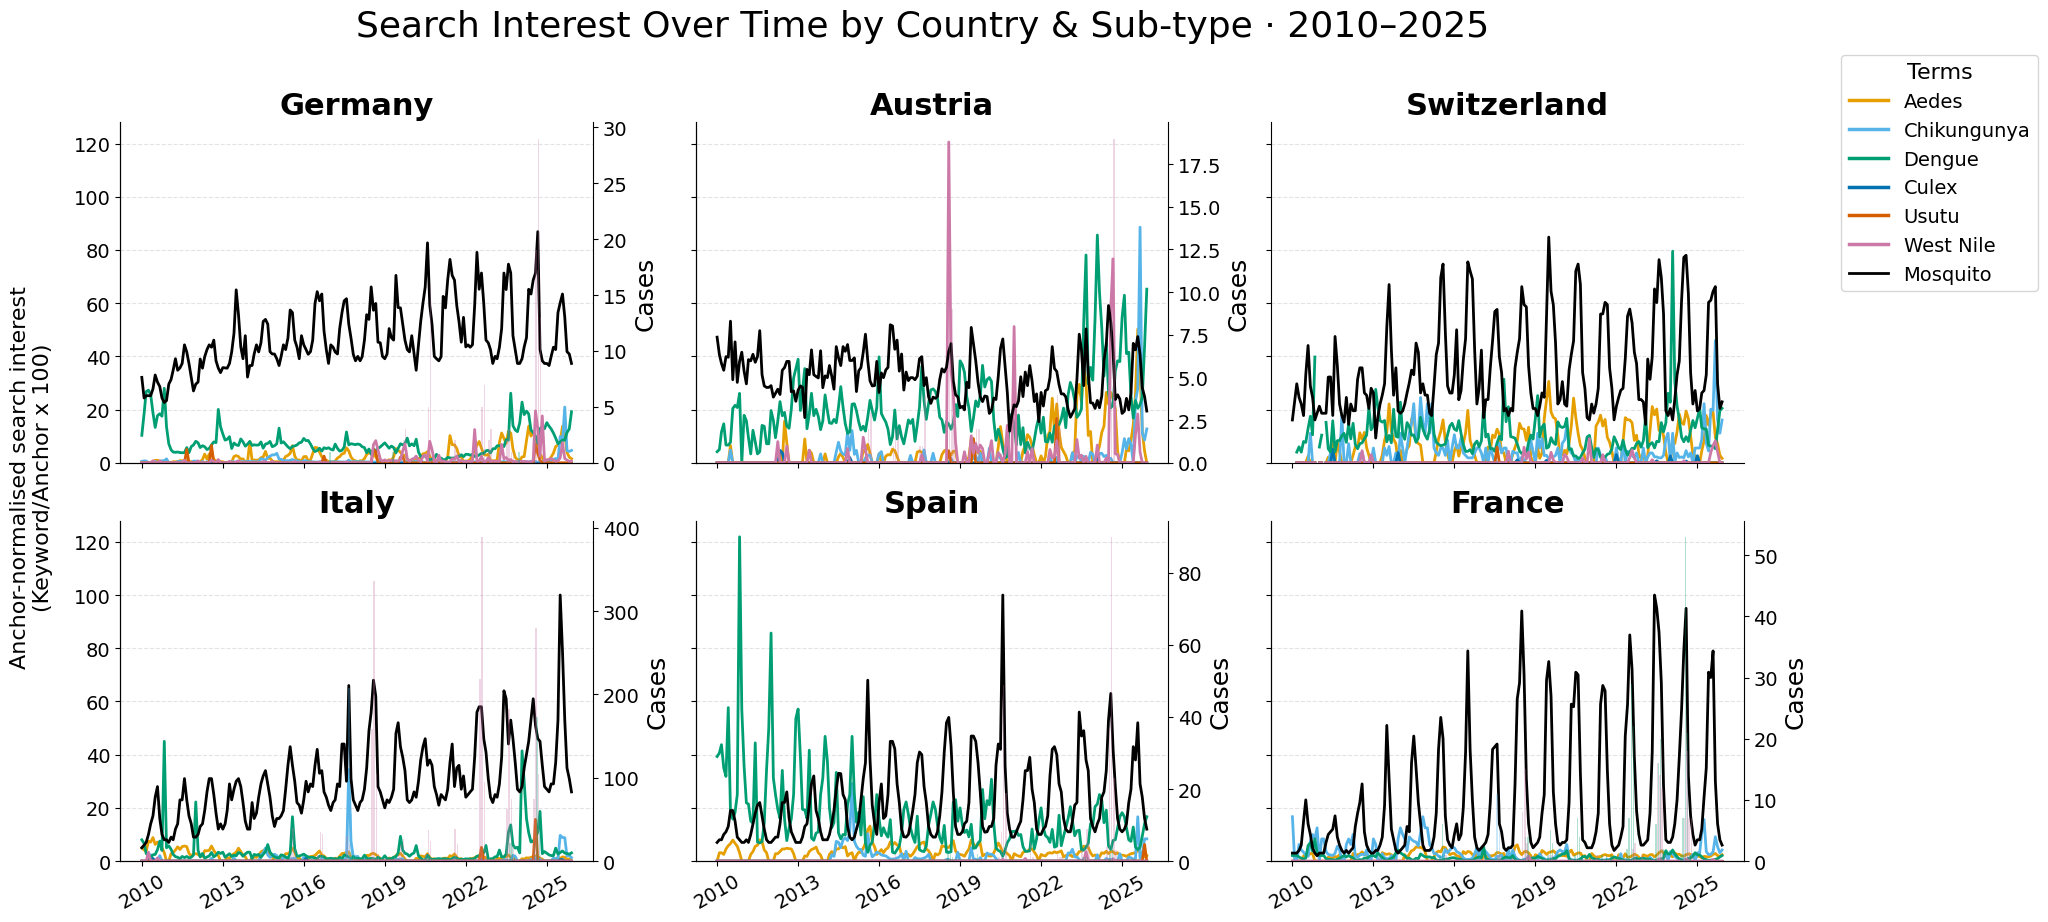

In [ ]:
def plot_timeseries(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
    anchor_series: dict[str, pd.Series] | None = None,
    save_path: Path | None = None,
) -> plt.Figure:

    subtype_to_system = {
        v["Sub-type"]: v["System"]
        for v in meta.values()
    }

    countries = [g for g in COUNTRY_ORDER if g in country_data]

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9),
        sharex=True,
        sharey=True,
    )

    axes_flat = axes.flatten()

    disease_lookup = {
        "Dengue": dengue,
        "Chikungunya": chik,
        "West Nile": wnv,
        "Zika": zika,
    }

    for ax, geo in zip(axes_flat, countries):

        df = country_data[geo]

        subtype_totals = subtype_means.loc[:, subtype_means.columns.str.startswith(f"{geo}::")]

        # ------------------------------------------------------------------
        # Plot search interest
        # ------------------------------------------------------------------
        for col, series in subtype_totals.items():
            
            series = series.copy()
            series.index = pd.to_datetime(series.index)
            series = series.sort_index()

            subtype = col.split("::")[1]   # ← FIX
            if subtype == "Zika":
                continue

            colour = SUBTYPE_COLOURS[subtype]

            ax.plot(
                series.index,
                series.values,
                color=colour,
                linewidth=2,
                linestyle="solid",
                label=subtype,
            )

        # ------------------------------------------------------------------
        # Anchor
        # ------------------------------------------------------------------
        if anchor_series and geo in anchor_series:

            anc = anchor_series[geo]

            ax.plot(
                anc.index,
                anc.values,
                color="black",
                linewidth=2,
                linestyle="solid",
                label="Mosquito",
            )

        # ------------------------------------------------------------------
        # ECDC case counts
        # ------------------------------------------------------------------
        disease_series = []

        for subtype, ddf in disease_lookup.items():

            if subtype == "Zika":
                continue

            country_name = COUNTRY_LABELS.get(geo, geo)
            dsub = ddf[ddf["country"] == country_name]

            if dsub.empty:
                continue

            dsub = dsub[
                (dsub["date"] >= "2015-01-01")
                & (dsub["date"] <= "2025-01-01")
            ].copy()

            if dsub.empty:
                continue

            dsub["Subtype"] = subtype
            disease_series.append(dsub)

        if disease_series:

            ax2 = ax.twinx()

            offsets = np.linspace(-10, 10, len(disease_series))

            for offset, dsub in zip(offsets, disease_series):

                subtype = dsub["Subtype"].iloc[0]

                colour = SUBTYPE_COLOURS.get(subtype, "grey")

                ax2.bar(
                    dsub["date"] + pd.to_timedelta(offset, unit="D"),
                    dsub["cases"],
                    width=20,
                    color=matplotlib.colors.to_rgba(colour, alpha=0.3),
                )

            ax2.set_ylabel("Cases", fontsize=18)
            ax2.tick_params(axis="y", labelsize=14)
            ax2.spines["top"].set_visible(False)

        # ------------------------------------------------------------------
        # Formatting
        # ------------------------------------------------------------------
        ax.set_title(
            COUNTRY_LABELS.get(geo, [geo]),
            fontsize=22,
            fontweight="bold",
        )

        ax.tick_params(axis="x", rotation=30, labelsize=14)
        ax.tick_params(axis="y", labelsize=14)

        ax.grid(axis="y", linestyle="--", alpha=0.35)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ----------------------------------------------------------------------
    # Axis formatting
    # ----------------------------------------------------------------------
    axes_flat[0].xaxis.set_major_locator(mdates.YearLocator(3))
    axes_flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ymax = axes_flat[0].get_ylim()[1]

    fig.text(
        0.005,
        0.5,
        "Anchor-normalised search interest\n(Keyword/Anchor x 100)",
        rotation="vertical",
        va="center", ha="center",
        fontsize=16,
    )

    # ----------------------------------------------------------------------
    # Legends
    # ----------------------------------------------------------------------
    subtype_handles = [
        mlines.Line2D(
            [],
            [],
            color=colour,
            linewidth=2.5,
            label=subtype,
        )
        for subtype, colour in SUBTYPE_COLOURS.items()
        if subtype in subtype_to_system and subtype != "Zika"
    ]

    anchor_handle = [
        mlines.Line2D(
            [],
            [],
            color="black",
            linewidth=2,
            linestyle="solid",
            label="Mosquito",
        )
    ]

    fig.legend(
        handles=subtype_handles + anchor_handle,
        title="Terms",
        title_fontsize=16,
        prop={"size": 14},
        loc="upper left",
        bbox_to_anchor=(1.005, 0.98),
        frameon=True,
    )

    fig.suptitle(
        "Search Interest Over Time by Country & Sub-type · 2010–2025",
        fontsize=26,
        y=1.02,
    )

    #fix yaxis
    for ax in axes_flat[:len(countries)]:
        ax.set_ylim(bottom=0)

    plt.tight_layout(rect=[0.02, 0, 1, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Chart saved → {save_path}")

    return fig

fig = plot_timeseries(
    country_data,
    meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "Appendix_anchor_no_zika.png",
)

plt.show()

## APPENDIX - Monthly time-series plots per country and subtype

C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_DE.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_AT.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


...

Chart saved → GoogleTrends_monthly_timeseries_IT.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_ES.png


C:\Users\annab\AppData\Local\Temp\ipykernel_56188\6570971.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → GoogleTrends_monthly_timeseries_FR.png
Zika chart saved → GoogleTrends_zika_by_country.png


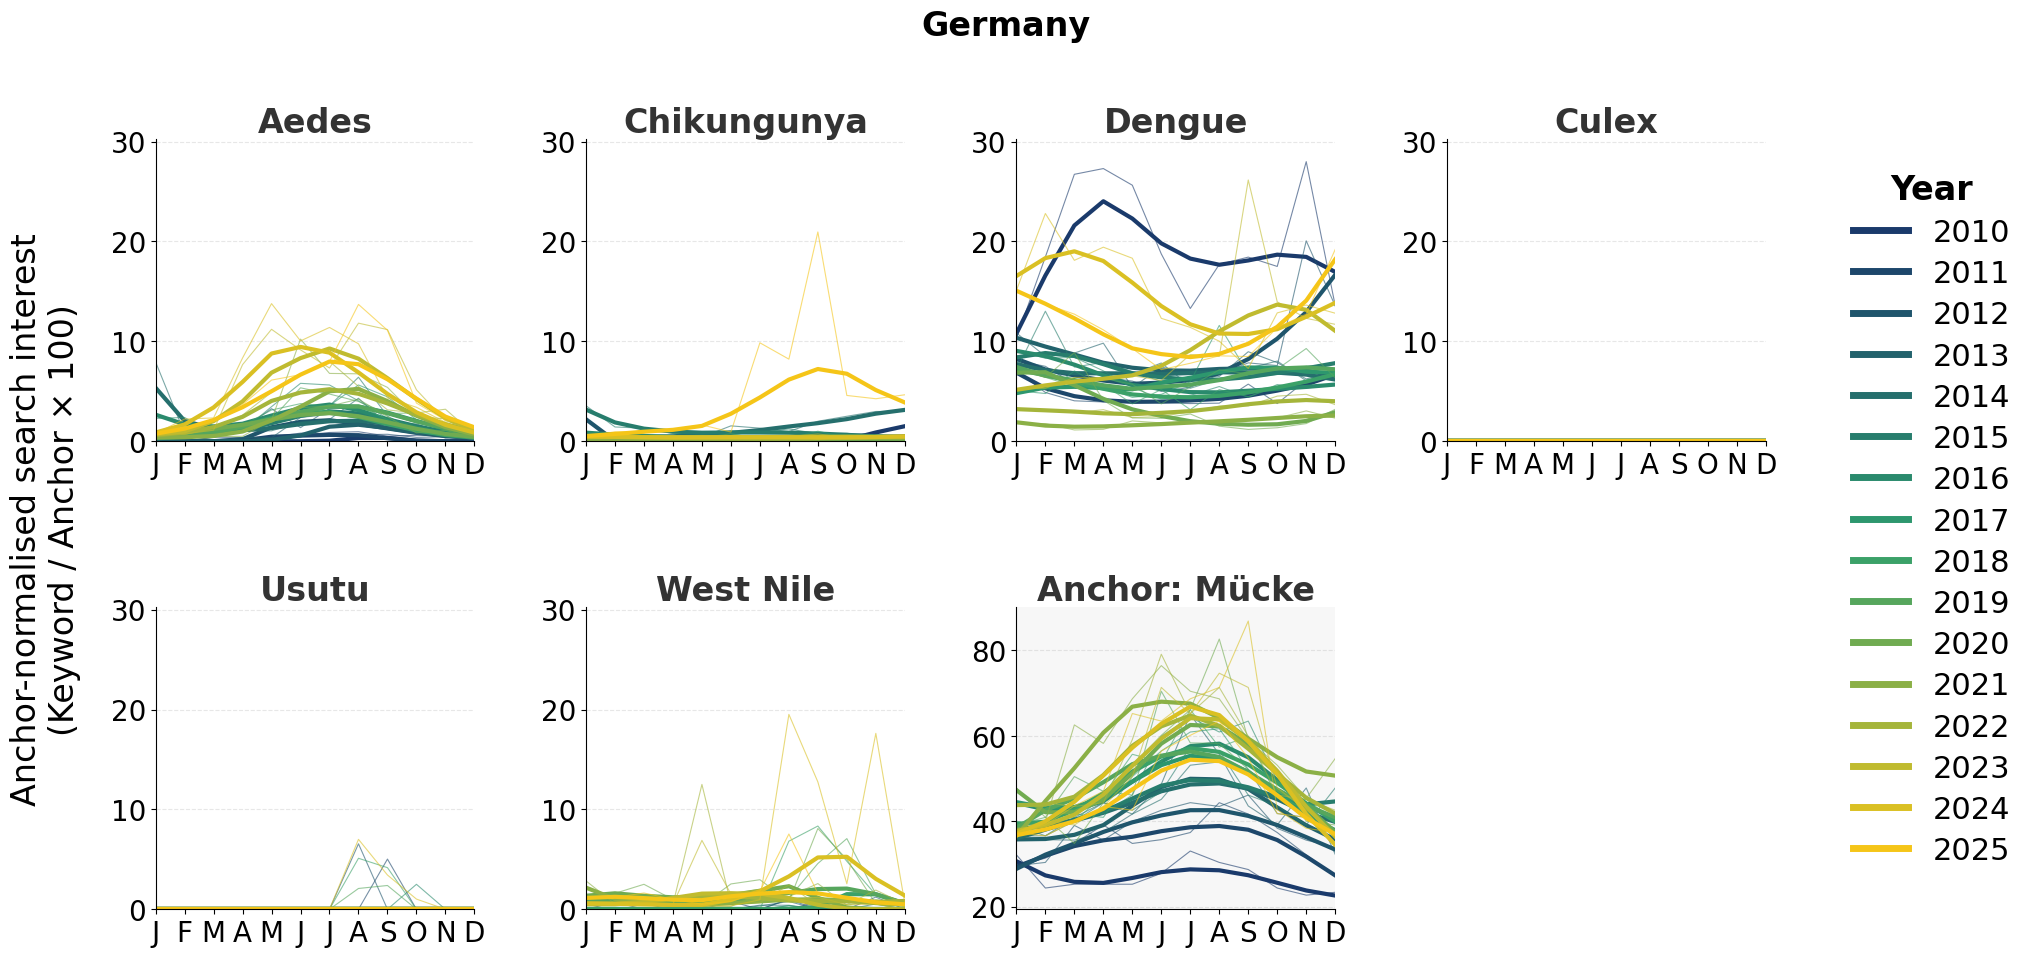

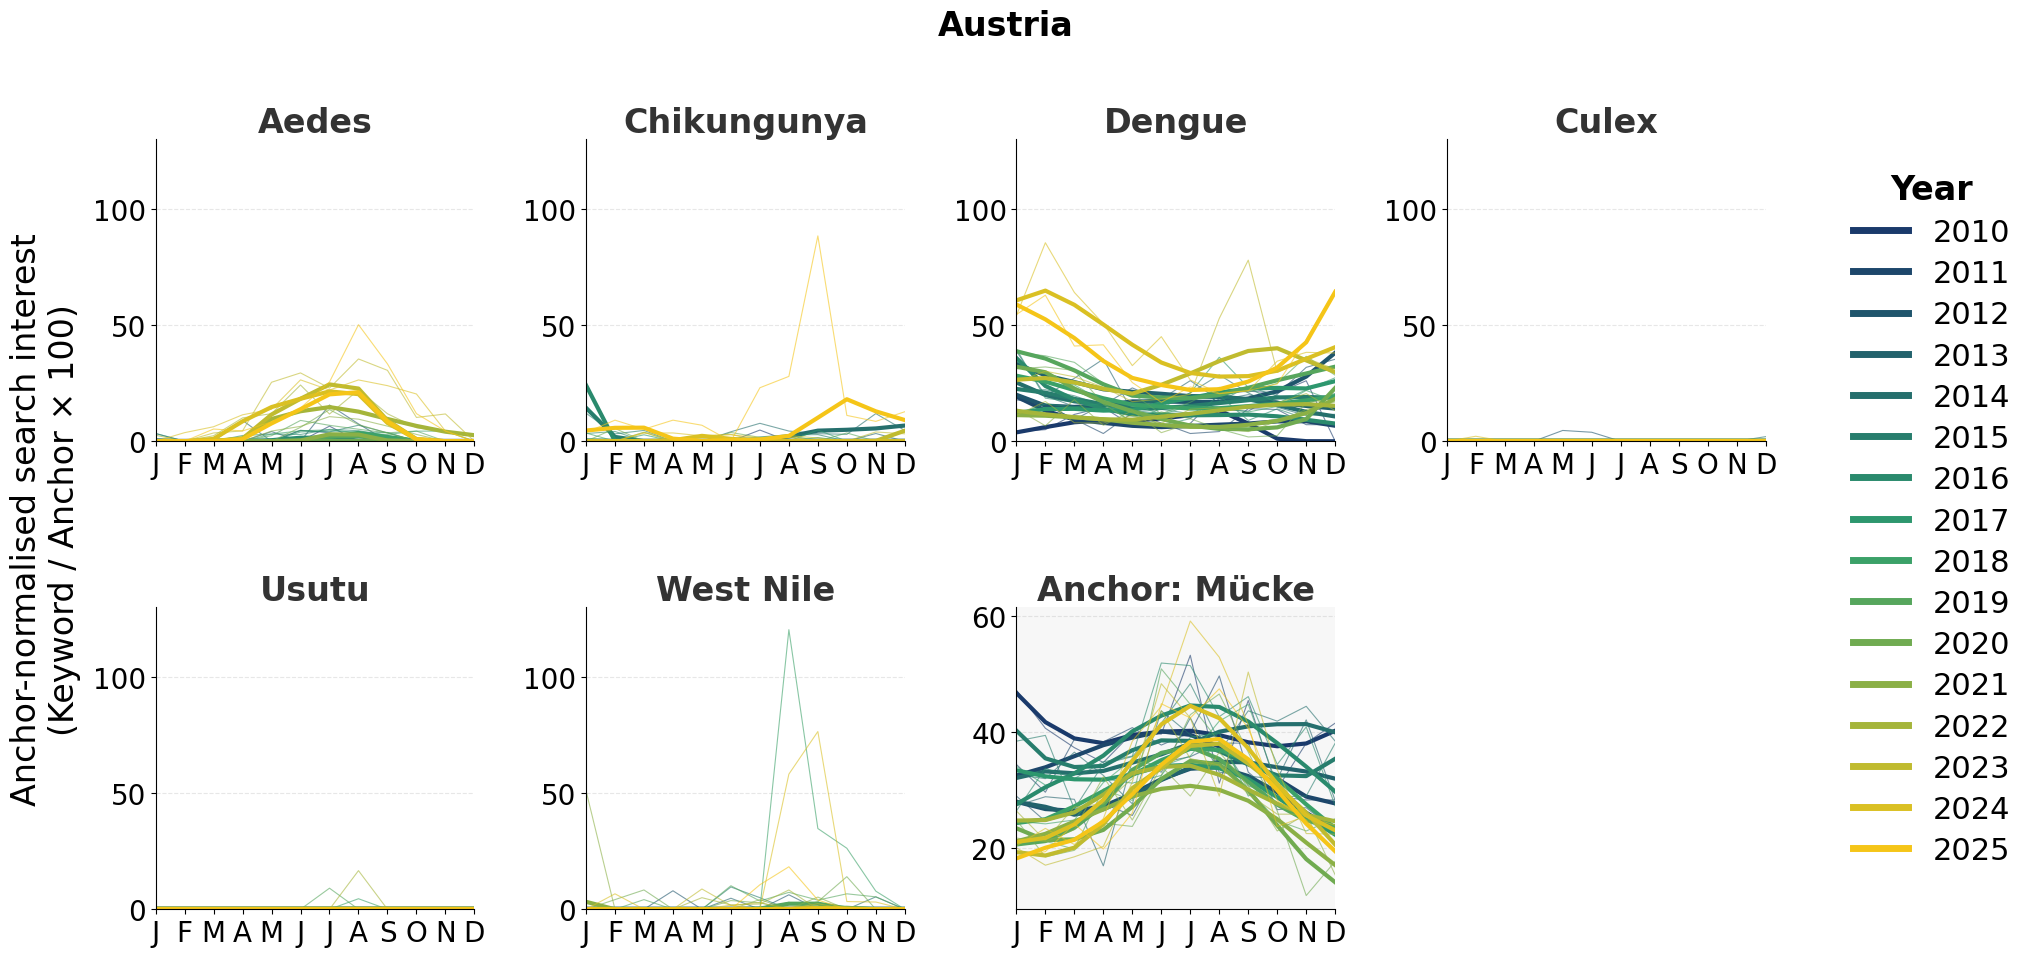

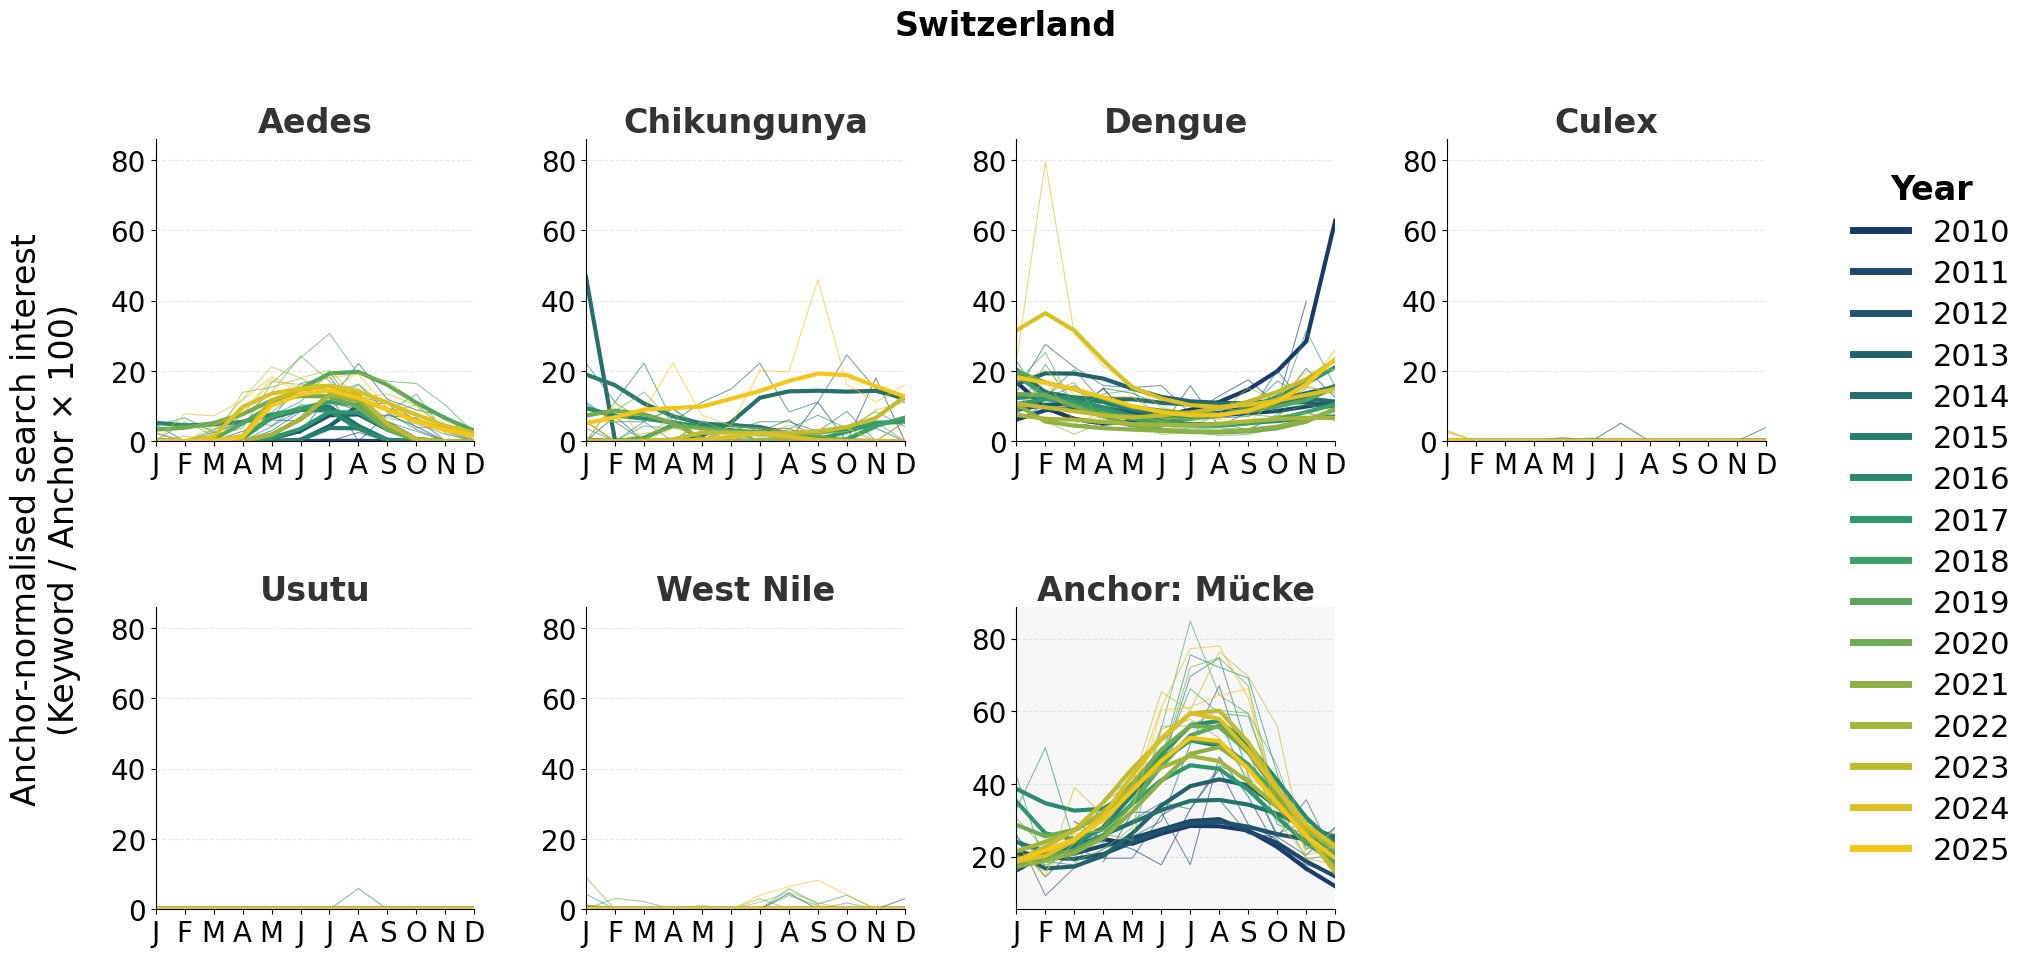

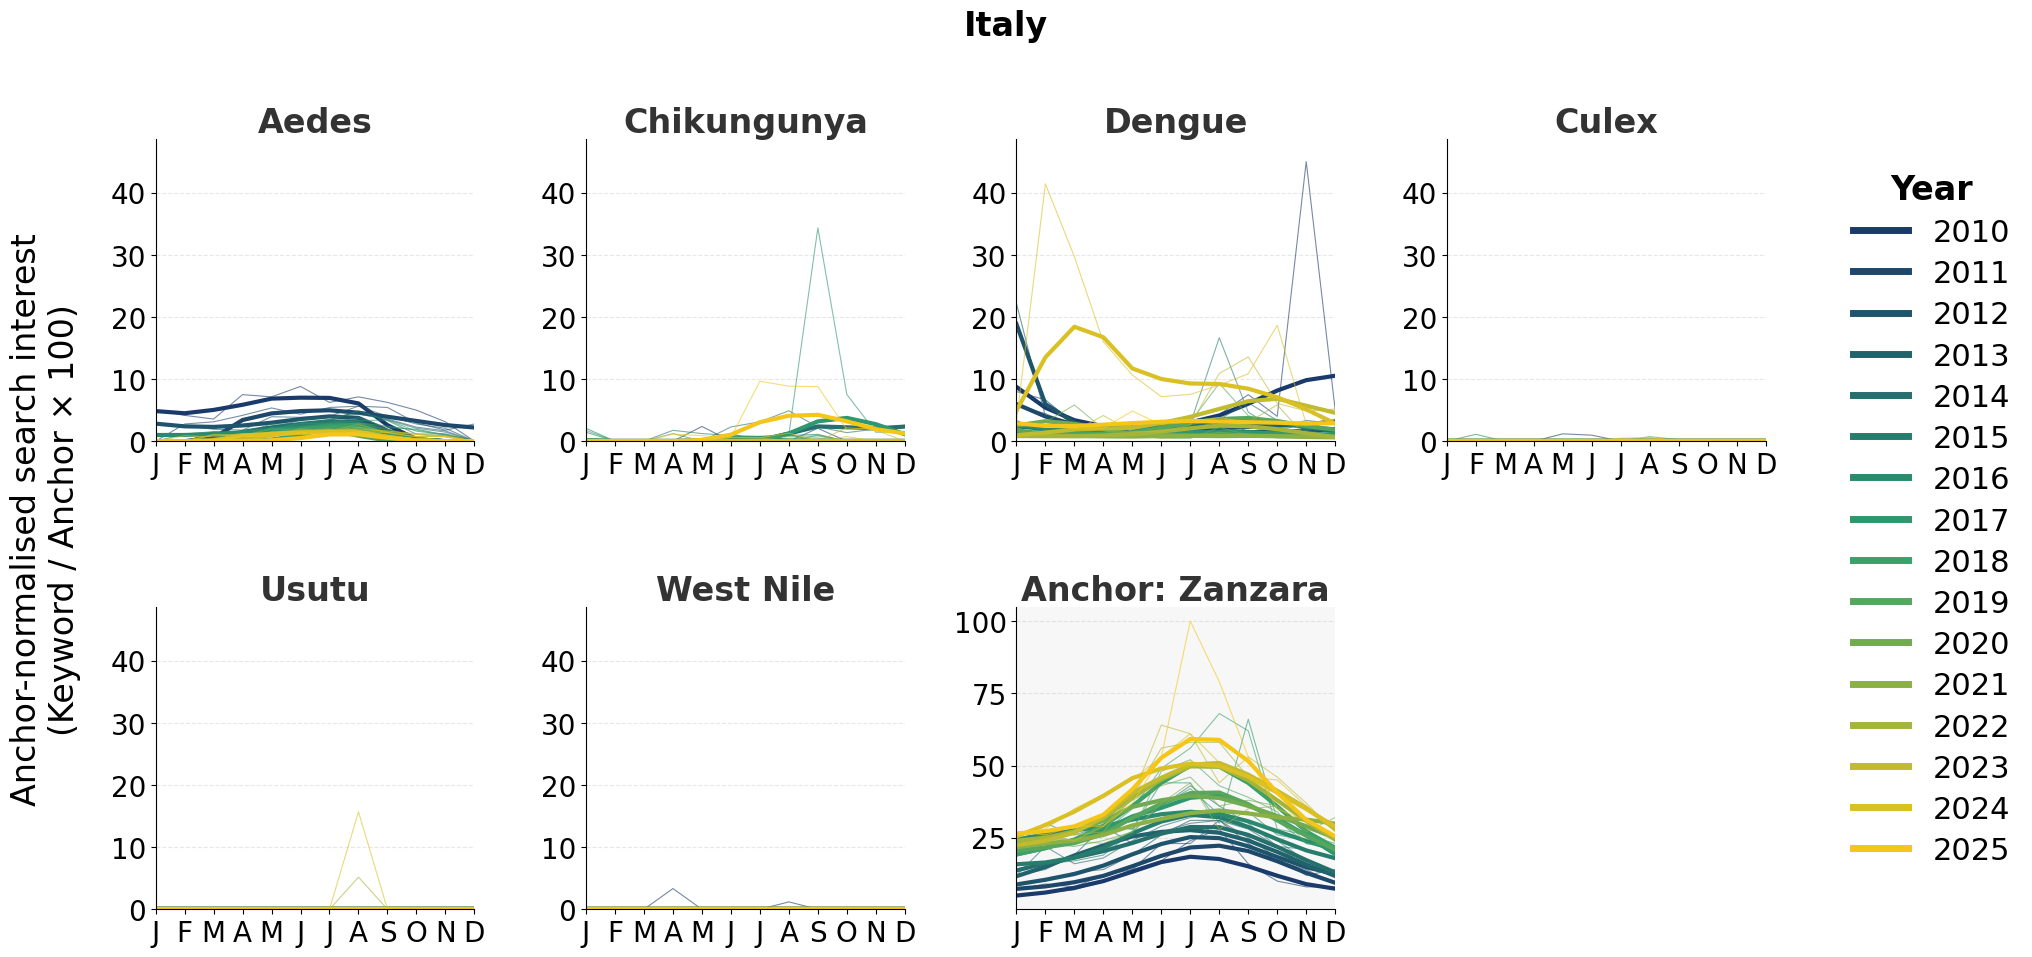

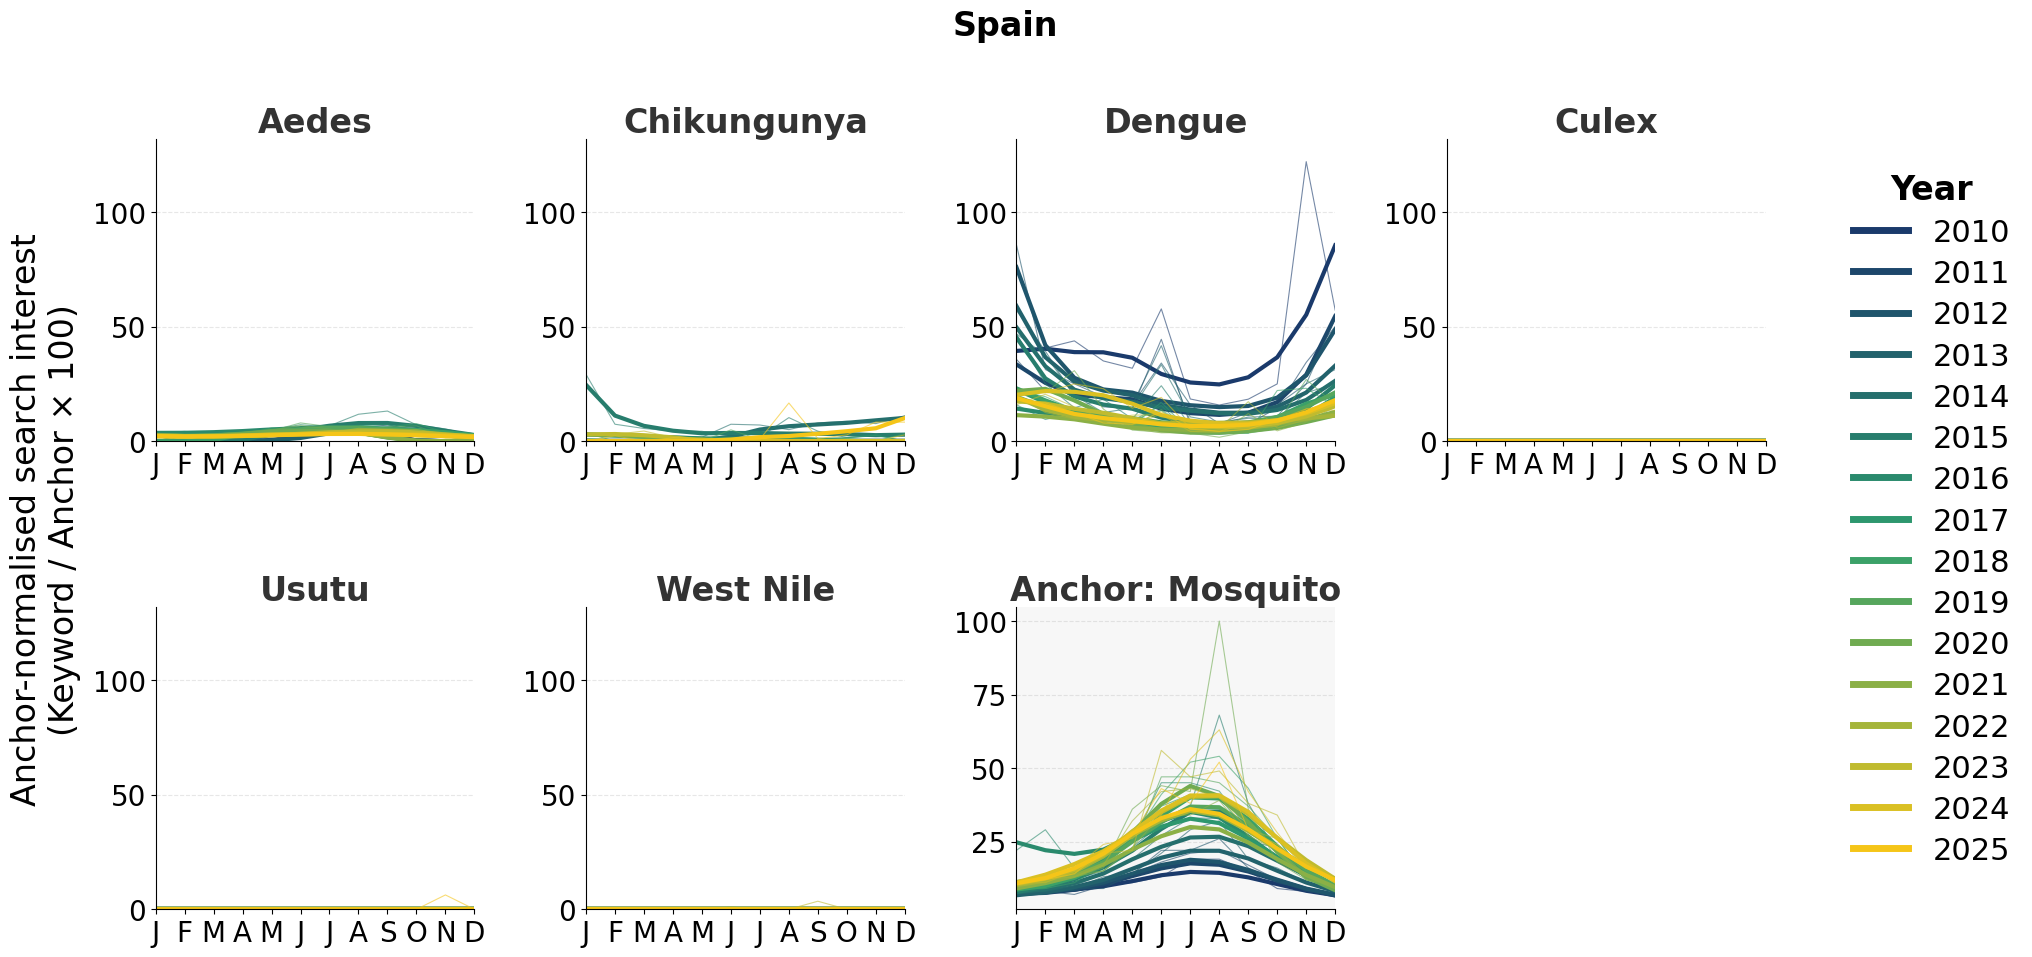

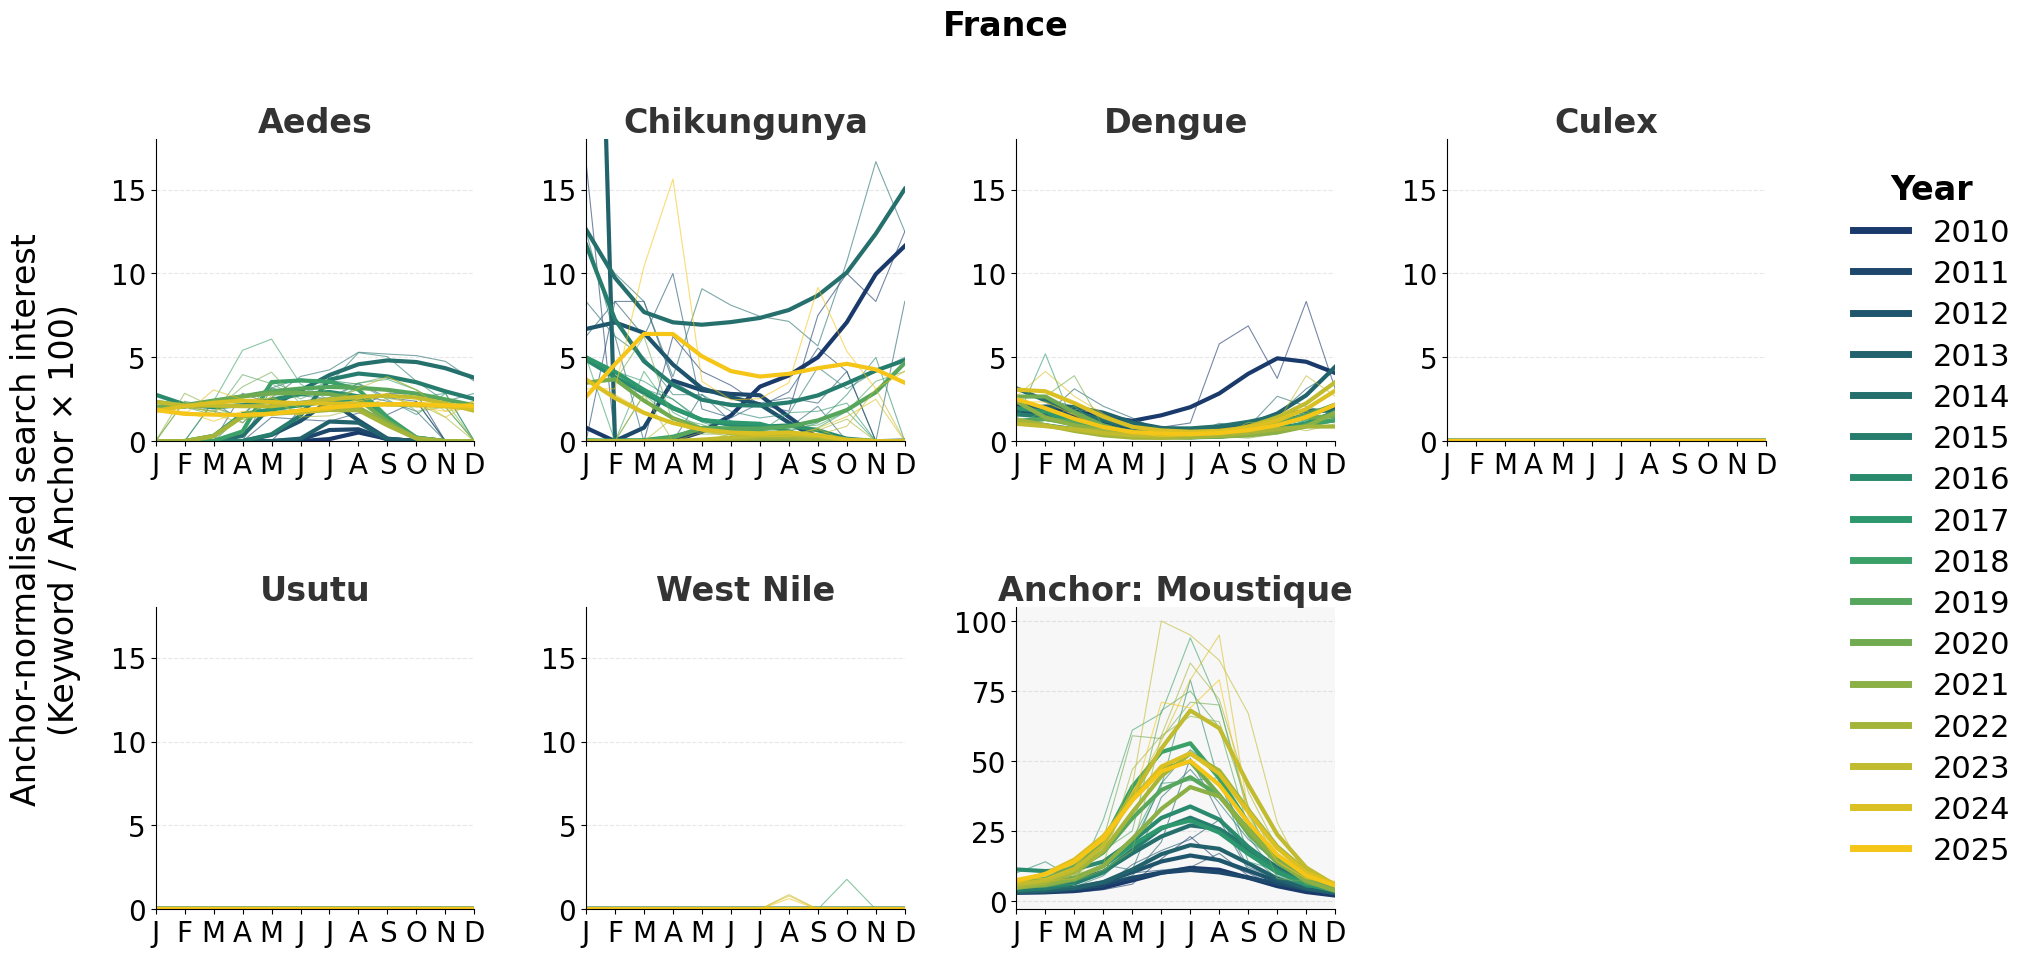

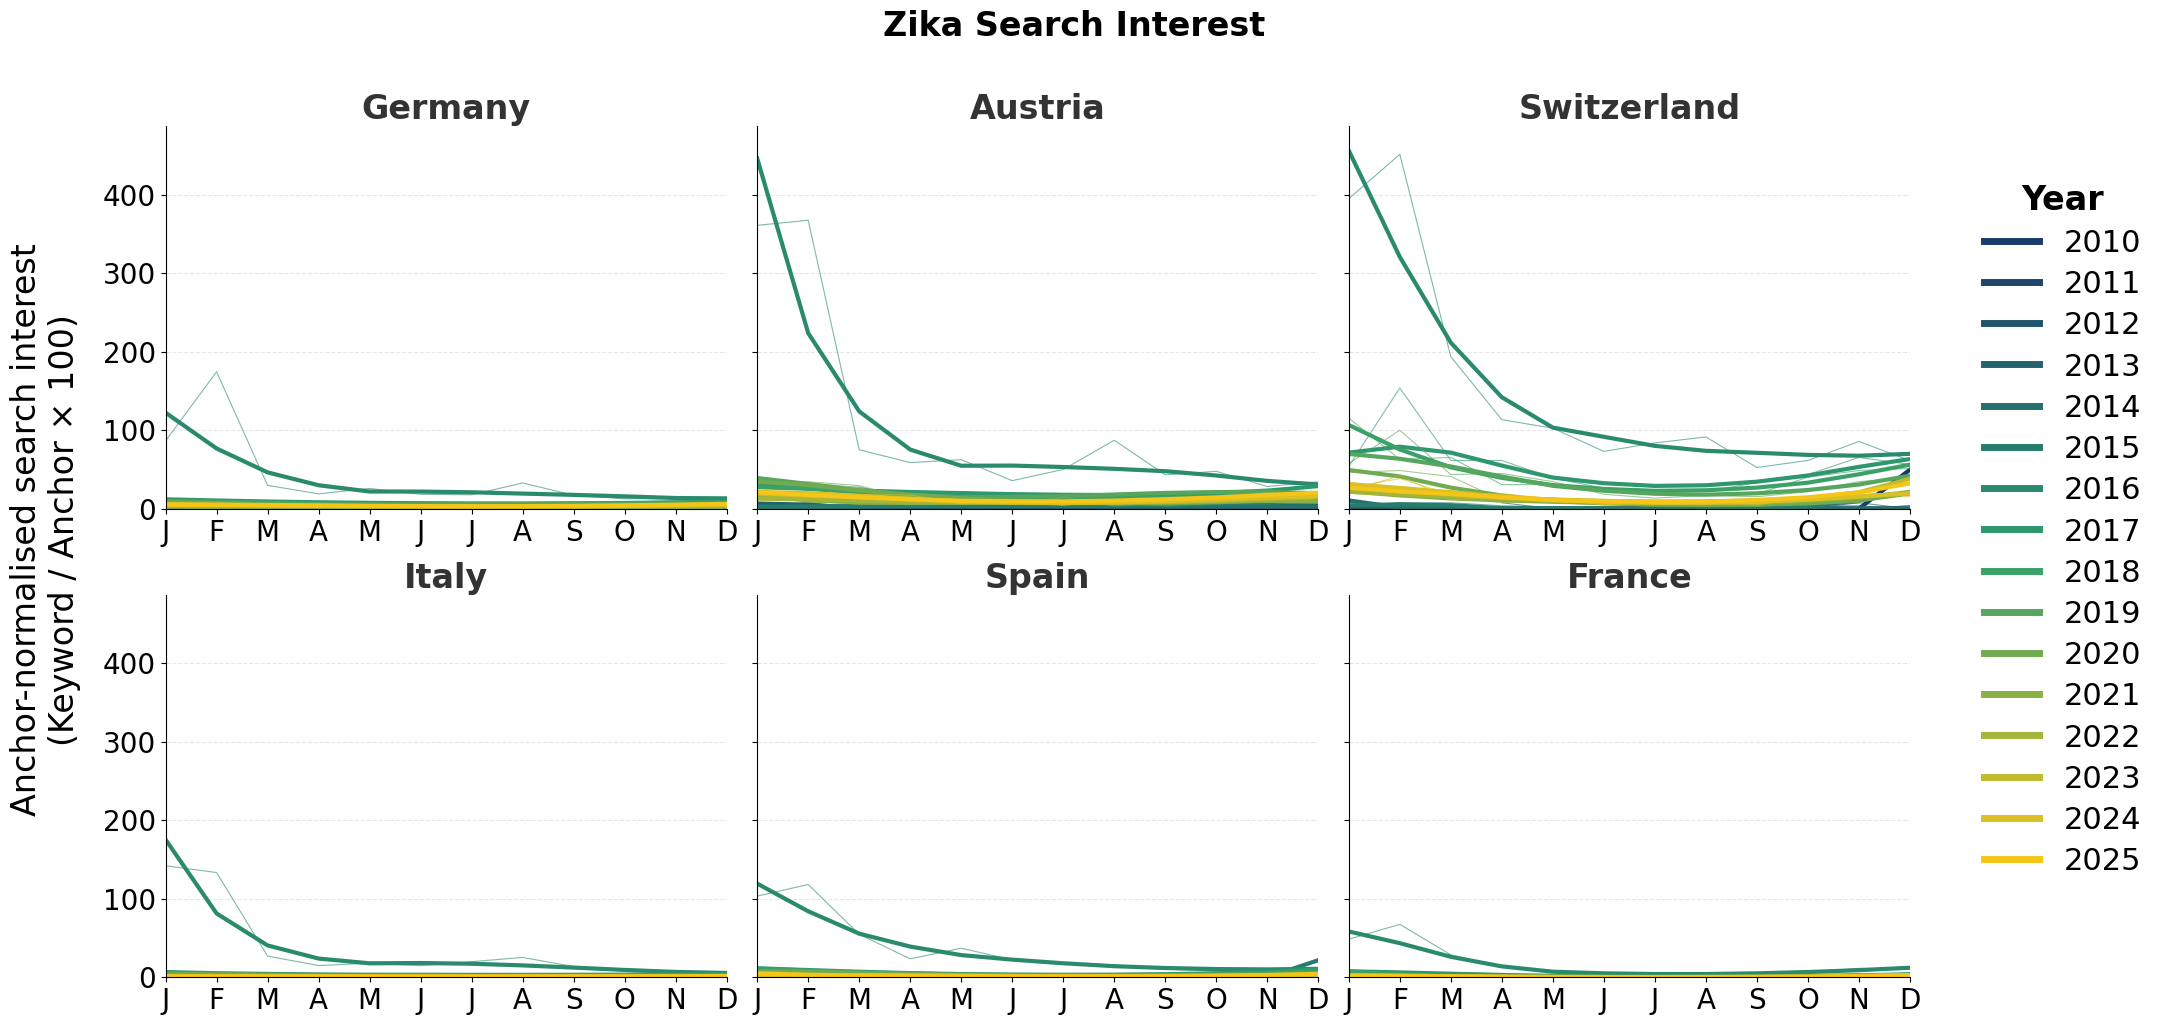

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM 3-STOP COLORMAP  (dark-blue → green → yellow, colourblind-safe)
# ─────────────────────────────────────────────────────────────────────────────

_GRADIENT_COLOURS = [
    "#1a3a6b",   # dark navy-blue  (early years)
    "#2e9e6e",   # teal-green      (middle years)
    "#f5c518",   # warm yellow     (recent years)
]
YEAR_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_green_yellow", _GRADIENT_COLOURS
)


# ─────────────────────────────────────────────────────────────────────────────
# SHARED PANEL-DRAWING HELPER
# ─────────────────────────────────────────────────────────────────────────────

def _draw_series_panel(
    ax,
    series: pd.Series,
    year_colour: dict,
    loess_frac: float,
    y_lim: tuple | None = None,
    title: str = "",
    title_colour: str = "#333333",
    facecolor: str | None = None,
    month_labels: list | None = None,
):
    """Draw one sub-panel: faint raw lines + bold LOESS lines, one per year."""
    if month_labels is None:
        month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    if facecolor:
        ax.set_facecolor(facecolor)

    for yr, yr_series in series.groupby(series.index.year):
        monthly = pd.Series(np.nan, index=range(1, 13), dtype=float)
        monthly.update(yr_series.set_axis(yr_series.index.month))
        colour = year_colour.get(yr, "grey")
        x_arr  = monthly.index.to_numpy(dtype=float)
        y_arr  = monthly.values.astype(float)

        ax.plot(x_arr, y_arr, color=colour, linewidth=0.8, alpha=0.6)
        smoothed = _loess(x_arr, y_arr, frac=loess_frac)
        ax.plot(x_arr, smoothed, color=colour, linewidth=3.0, alpha=1)

    ax.set_title(title, fontsize=24, fontweight="bold", color=title_colour, pad=4)  # changed: 18 → 24
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=20, ha="center")  # changed: 16 → 20, added ha="center"
    ax.set_xlim(1, 12)
    ax.tick_params(axis="y", labelsize=20)  # changed: 7 → 20
    ax.margins(x=0)  # added: removes gap between y-axis and plot data
    if y_lim:
        ax.set_ylim(*y_lim)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


def _add_year_legend(fig, norm, years_sorted, right_x=0.91):
    """
    Discrete line-swatch legend (one coloured entry per year) placed on the
    right margin — same style as the reference image.
    """
    handles = [
        mlines.Line2D(
            [], [],
            color=YEAR_CMAP(norm(yr)),
            linewidth=5,
            label=str(yr),
        )
        for yr in years_sorted
    ]
    leg = fig.legend(
        handles=handles,
        title="Year",
        title_fontsize=24,  # changed: 18 → 20
        fontsize=22,        # changed: 18 → 20
        loc="center left",
        bbox_to_anchor=(right_x, 0.5),
        frameon=False,
        handlelength=1.8,
        handleheight=0.8,
        labelspacing=0.4,
    )
    leg.get_title().set_fontweight("bold")


# ─────────────────────────────────────────────────────────────────────────────
# COUNTRY FIGURES  (Zika excluded)
# ─────────────────────────────────────────────────────────────────────────────

def plot_timeseries(
    df: pd.DataFrame,
    meta: dict,
    anchor_series: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> list[plt.Figure]:
    """
    One figure per country, 4×2 grid of sub-panels.
    Zika is excluded from these panels; call plot_zika_figure() separately.

    Panels (in order): non-Zika subtypes, then anchor (if provided), then empty.
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    N_COLS, N_ROWS = 4, 2
    MAX_PANELS = N_COLS * N_ROWS

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples   = [c.split("::") for c in df.columns]
    all_geos     = list(dict.fromkeys(t[0] for t in col_tuples))
    all_subtypes = list(dict.fromkeys(t[1] for t in col_tuples))

    countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos

    subtypes_order = [s for s in SUBTYPE_COLOURS if s in all_subtypes]
    subtypes_order += [s for s in all_subtypes if s not in subtypes_order]

    # Remove Zika from per-country panels
    subtypes_order = [s for s in subtypes_order if s != zika_subtype]

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    figures = []

    for geo in countries:
        geo_cols = {t[1]: f"{geo}::{t[1]}" for t in col_tuples if t[0] == geo}
        subtypes_present = [s for s in subtypes_order if s in geo_cols]

        has_anchor = anchor_series is not None and geo in anchor_series
        n_subtype_slots = MAX_PANELS - (1 if has_anchor else 0)
        subtypes_show = subtypes_present[:n_subtype_slots]

        panel_list = subtypes_show[:]
        if has_anchor:
            panel_list.append("__anchor__")
        panel_list += [None] * (MAX_PANELS - len(panel_list))

        try:
            country_label = COUNTRY_LABELS.get(geo, geo)
        except NameError:
            country_label = geo

        fig = plt.figure(figsize=(20, 10))
        fig.suptitle(
            f"{country_label}",
            fontsize=24, fontweight="bold", y=1.01,  # unchanged: already 24
        )

        outer = gridspec.GridSpec(
            N_ROWS, N_COLS, figure=fig,
            hspace=0.55, wspace=0.35, right=0.88, left=0.075,
        )

        # Shared y-range: exclude Zika columns so scale isn't distorted
        non_zika_cols = [
            c for c in df.columns
            if c.startswith(f"{geo}::") and not c.endswith(f"::{zika_subtype}")
        ]
        country_data = df[non_zika_cols] if non_zika_cols else df[
            [c for c in df.columns if c.startswith(f"{geo}::")]
        ]
        y_max = np.nanmax(country_data.values)
        y_pad = y_max * 0.08 or 1
        y_lim = (0, y_max + y_pad)

        for idx, panel in enumerate(panel_list):
            row, col = divmod(idx, N_COLS)
            ax = fig.add_subplot(outer[row, col])

            if panel is None:
                ax.set_visible(False)
                continue

            if panel == "__anchor__":
                anc = anchor_series[geo].copy()
                anc.index = pd.to_datetime(anc.index)
                try:
                    anchor_word = ANCHOR_PER_COUNTRY.get(geo, "anchor")
                except NameError:
                    anchor_word = "anchor"
                _draw_series_panel(
                    ax, anc, year_colour, loess_frac,
                    y_lim=None,
                    title=f"Anchor: {anchor_word}",
                    facecolor="#f7f7f7",
                    month_labels=MONTH_LABELS,
                )
                continue

            series = df[geo_cols[panel]]

            _draw_series_panel(
                ax, series, year_colour, loess_frac,
                y_lim=y_lim,
                title=panel,
                month_labels=MONTH_LABELS,
            )

        fig.supylabel(
            "Anchor-normalised search interest\n(Keyword / Anchor × 100)",
            fontsize=24, ha="center",
        )

        _add_year_legend(fig, norm, years_sorted)
        plt.tight_layout(rect=[0.03, 0, 0.90, 1])

        if save_path:
            out = save_path.parent / f"{save_path.stem}_{geo}{save_path.suffix}"
            fig.savefig(out, dpi=150, bbox_inches="tight")
            print(f"Chart saved → {out}")

        figures.append(fig)

    return figures


# ─────────────────────────────────────────────────────────────────────────────
# ZIKA FIGURE  (one panel per country, all on one figure)
# ─────────────────────────────────────────────────────────────────────────────

def plot_zika_figure(
    df: pd.DataFrame,
    meta: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> plt.Figure:
    """
    Single figure with one panel per country showing Zika search interest.
    Layout: up to 3 columns, rows as needed.
    Lines = years (same blue→green→yellow gradient as the country figures).
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]
    all_geos   = list(dict.fromkeys(t[0] for t in col_tuples))

    try:
        countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos
    except NameError:
        countries = all_geos

    zika_cols = {
        geo: f"{geo}::{zika_subtype}"
        for geo in countries
        if f"{geo}::{zika_subtype}" in df.columns
    }
    countries_with_zika = [g for g in countries if g in zika_cols]

    if not countries_with_zika:
        print("[warn] No Zika columns found in DataFrame.")
        return plt.figure()

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    n     = len(countries_with_zika)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 5 * nrows),
        sharey=True,
        squeeze=False,
    )
    axes_flat = axes.flatten()

    zika_values = df[[v for v in zika_cols.values()]].values
    y_max = np.nanmax(zika_values)
    y_pad = y_max * 0.08 or 1
    y_lim = (0, y_max + y_pad)

    for i, geo in enumerate(countries_with_zika):
        ax = axes_flat[i]
        series = df[zika_cols[geo]]

        try:
            country_label = COUNTRY_LABELS.get(geo, geo)
        except NameError:
            country_label = geo

        _draw_series_panel(
            ax, series, year_colour, loess_frac,
            y_lim=y_lim,
            title=country_label,
            month_labels=MONTH_LABELS,
        )

    for ax in axes_flat[len(countries_with_zika):]:
        ax.set_visible(False)

    fig.suptitle(
        "Zika Search Interest",
        fontsize=24, fontweight="bold", y=1.02,  # unchanged: already 24
    )
    fig.text(
        0.01, 0.5,
        "Anchor-normalised search interest\n(Keyword / Anchor × 100)",
        va="center", ha="center",  # added: ha="center"
        rotation="vertical", fontsize=24,  # changed: 18 → 20
    )

    _add_year_legend(fig, norm, years_sorted, right_x=0.92)
    plt.tight_layout(rect=[0.03, 0, 0.91, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Zika chart saved → {save_path}")

    return fig


# ─────────────────────────────────────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────────────────────────────────────

figs = plot_timeseries(
    subtype_means, meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "GoogleTrends_monthly_timeseries.png",
)

fig_zika = plot_zika_figure(
    subtype_means, meta,
    save_path=OUTPUT_PATH / "GoogleTrends_zika_by_country.png",
)

plt.show()